# تحليل تجارة إلكترونية — نسخة محسّنة v2

**ملاحظة مهمّة بخصوص "الكمّية":** بما أنّ ملف البيانات لا يحتوي عمود **Quantity** حقيقي، قمتُ بإضافة خيار **اختياري** لتعريف **Proxy Quantity** (=1 لكل صف) فقط إذا رغبت بذلك. بشكلٍ افتراضي **لن نستعمل كمية افتراضية** وسنعتمد على **عدد العمليات (count)** و**قيمة الشراء (Purchase Amount)**؛ وهذا أدقّ وأفضل أكاديميًا من اختراع كميات.

- الإصدار: v2  
- التاريخ: 2025-08-25 14:53:05


## 1) الإعدادات وتحميل البيانات

- حدّد مسار ملف CSV في المتغيّر `DATA_PATH` إن كان متوفّرًا لديك.  
- إذا لم يكن متوفّرًا لديك الآن، اتركه فارغًا وستُعرض خلايا الشرح فقط لحين توفير الملف.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [50]:
# ==== Arabic setup (fonts + optional shaping) — put this as the FIRST cell ====
import warnings, importlib, re
import matplotlib as mpl
from matplotlib.text import Text as _MplText
from matplotlib import font_manager as fm

# 1) اختر خط فعلي موجود على جهازك (Windows عادة: Tahoma أو Arial)
available = {f.name for f in fm.fontManager.ttflist}
preferred = ["Tahoma", "Arial", "DejaVu Sans"]  # نختار الموجود بينها
chosen = next((f for f in preferred if f in available), None)

if chosen is None:
    # fallback آمن
    chosen = "DejaVu Sans"

mpl.rcParams["font.family"] = chosen
mpl.rcParams["axes.unicode_minus"] = False  # علامة السالب مع العربية

# 2) أسكت رسائل "findfont: Font family '... ' not found."
warnings.filterwarnings("ignore", message=r"findfont: Font family '.*' not found\.")

print(f"✅ Using font family: {mpl.rcParams['font.family']}")

# 3) (اختياري) تشكيل/اتجاه العربية تلقائيًا إن توفّرت المكتبات
try:
    arabic_reshaper = importlib.import_module("arabic_reshaper")
    _bidi_algo = importlib.import_module("bidi.algorithm")
    get_display = getattr(_bidi_algo, "get_display", None)
except Exception:
    arabic_reshaper, get_display = None, None

# ألغِ أي باتش سابق لمنع RecursionError
if hasattr(_MplText, "_arabic_orig_set_text"):
    _MplText.set_text = _MplText._arabic_orig_set_text
    delattr(_MplText, "_arabic_orig_set_text")
if hasattr(_MplText, "_arabic_patched"):
    delattr(_MplText, "_arabic_patched")

_arabic_re = re.compile(r"[\u0600-\u06FF]")
_orig_set_text = _MplText.set_text

def _normalize_arabic(s):
    if not isinstance(s, str) or not _arabic_re.search(s):
        return s
    try:
        if arabic_reshaper is not None and get_display is not None:
            return get_display(arabic_reshaper.reshape(s))
    except Exception:
        pass
    return s

def _set_text_ar(self, s):
    return _orig_set_text(self, _normalize_arabic(s))

_MplText._arabic_orig_set_text = _orig_set_text
_MplText.set_text = _set_text_ar
_MplText._arabic_patched = True

print("🔤 Arabic shaping:", bool(arabic_reshaper and get_display))


✅ Using font family: ['Tahoma']
🔤 Arabic shaping: True


# 2 تحميل البيانات من ملف CSV

In [51]:
plt.rcParams['figure.figsize'] = (8,5)

# ضع مسار ملف CSV هنا لو كان موجود عندك محليًا:
DATA_PATH = r"D:\Third year\Machine Learning and Neural Networks Eng. Muhannad Muawadah\AI Group 2\ML\E-Commerce-Sales-Data.enhanced_clean.csv"# مثال: "E-Commerce-Sales-Data.csv"

# استخدام كمية افتراضية؟ (Proxy Quantity=1 لكل صف)
USE_PROXY_QUANTITY = True  # اجعله True فقط إذا احتجت "عدد الوحدات" تقريبياً

df = None
if DATA_PATH:
    try:
        df = pd.read_csv(DATA_PATH, encoding="utf-8")
        print("Loaded:", df.shape, "from", DATA_PATH)
    except Exception as e:
        print("تعذّر التحميل من DATA_PATH:", e)

df  # سيظهر None إذا لم تُحمِّل الملف بعد


Loaded: (3900, 26) from D:\Third year\Machine Learning and Neural Networks Eng. Muhannad Muawadah\AI Group 2\ML\E-Commerce-Sales-Data.enhanced_clean.csv


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Payment Method,Frequency of Purchases,Quantity,Material,Discount_Flag,Promo_Flag,Sub_Flag,Freq_Ordinal,AgeGroup,Proxy_Quantity
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Venmo,Fortnightly,1,Other,1,1,1,NaN,55-64,1
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Cash,Fortnightly,1,Other,1,1,1,NaN,18-24,1
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Credit Card,Weekly,1,Other,1,1,1,4.0,45-54,1
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,PayPal,Weekly,1,Other,1,1,1,4.0,18-24,1
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,PayPal,Annually,1,Other,1,1,1,1.0,45-54,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,Venmo,Weekly,1,Other,0,0,0,4.0,35-44,1
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,Bank Transfer,Bi-Weekly,1,Other,0,0,0,NaN,45-54,1
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,Venmo,Quarterly,1,Other,0,0,0,2.0,45-54,1
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,Venmo,Weekly,1,Other,0,0,0,4.0,35-44,1


## 2) ما هي البيانات؟ (قاموس بيانات مُبسّط)

> يوضّح معنى كل عمود، ونوعه، وعدد القيم الفريدة والمفقودة.


In [52]:


def describe_dataset(df: pd.DataFrame):
    if df is None:
        print("⚠️ لم يتم تحميل بيانات بعد. عيّن DATA_PATH أولاً.")
        return None

    def infer(col, series: pd.Series):
        name = col.lower()
        tags = []

        # حدود كلمات لتفادي agegroup
        if re.search(r'\bcustomer\s*id\b', name): tags.append('معرّف العميل')
        if re.search(r'\bage\b', name): tags.append('العمر (رقمي)')
        if re.search(r'\bage[_\s-]*group\b', name): 
            tags = ['فئة عمرية (اسمية)']  # يطغى على "العمر (رقمي)"

        if re.search(r'\bgender\b', name): tags.append('الجنس')
        if re.search(r'\bitem[_\s-]*purchased\b', name): tags.append('العنصر/المنتج')
        if re.search(r'\bcategory\b', name): tags.append('الفئة')
        if re.search(r'\bpurchase[_\s-]*amount|\(usd\)', name): tags.append('قيمة الشراء (USD)')
        if re.search(r'\blocation\b', name): tags.append('الموقع/الولاية')
        if re.search(r'\bsize\b', name): tags.append('المقاس')
        if re.search(r'\bcolor\b', name): tags.append('اللون')
        if re.search(r'\bseason\b', name): tags.append('الموسم')
        if re.search(r'\breview[_\s-]*rating|rating\b', name): tags.append('تقييم المراجعة (رقمي)')
        if re.search(r'\bsubscription[_\s-]*status\b', name): tags.append('حالة الاشتراك (Yes/No)')
        if re.search(r'\bshipping[_\s-]*type\b', name): tags.append('نوع الشحن')
        if re.search(r'\bdiscount[_\s-]*applied\b', name): tags.append('هل وُجد خصم؟')
        if re.search(r'\bpromo[_\s-]*code[_\s-]*used\b', name): tags.append('هل استُخدم كود ترويجي؟')
        if re.search(r'\bprevious[_\s-]*purchases\b', name): tags.append('عدد المشتريات السابقة (رقمي)')
        if re.search(r'\bpayment[_\s-]*method\b', name): tags.append('طريقة الدفع')
        if re.search(r'\bfrequency[_\s-]*of[_\s-]*purchases\b', name): tags.append('تكرار الشراء (ترتيبي)')

        # تغطية الأعمدة المهندسة/الاختصارات
        if re.search(r'\bqty\b|\bquantity\b|\bunits?\b', name): tags.append('الكمية (رقمي)')
        if re.search(r'\bproxy[_\s-]*quantity\b', name): tags.append('الكمية (افتراضية=1)')
        if re.search(r'\bfreq[_\s-]*ordinal\b', name): tags.append('تكرار الشراء (مرقّم)')
        if re.search(r'\bmaterial\b', name): tags.append('الخامة/المادة')
        if re.search(r'\bflag\b|_flag$', name): tags.append('مؤشر/علم ثنائي (0/1)')

        # ذكاء بنيوي إضافي لو ما طلع شيء
        nunq = series.nunique(dropna=False)
        dtype = str(series.dtype)

        if not tags:
            # ثنائي
            if (np.issubdtype(series.dropna().astype(str).str.fullmatch(r'[01]').fillna(False).values.dtype, np.bool_) 
                or nunq == 2 and (dtype.startswith('int') or dtype.startswith('float'))):
                tags.append('مؤشر ثنائي (0/1)')
            # عمود ثابت
            elif nunq == 1:
                tags.append('ثابت (قيمة واحدة فقط)')
            # نص قليل القيم
            elif dtype == 'object' and nunq <= 10:
                tags.append('فئة/تصنيف (قليل القيم)')
            # أعداد صحيحة
            elif dtype.startswith('int'):
                tags.append('رقمي (عدد صحيح)')
            # أعداد عشرية
            elif dtype.startswith('float'):
                tags.append('رقمي (عشري)')

        return ', '.join(dict.fromkeys(tags)) if tags else '—'  # إزالة التكرار مع الحفاظ على الترتيب

    dd = pd.DataFrame({
        "العمود": df.columns,
        "الدلالة (مستنتجة)": [infer(c, df[c]) for c in df.columns],
        "نوع البيانات": [str(df[c].dtype) for c in df.columns],
        "قيم مفقودة": [int(df[c].isna().sum()) for c in df.columns],
        "عدد القيم الفريدة": [int(df[c].nunique(dropna=False)) for c in df.columns],
    })
    return dd
data_dict = describe_dataset(df)
data_dict 

,العمود,الدلالة (مستنتجة),نوع البيانات,قيم مفقودة,عدد القيم الفريدة
0,Customer ID,معرّف العميل,int64,0,3900
1,Age,العمر (رقمي),int64,0,53
2,Gender,الجنس,object,0,2
3,Item Purchased,العنصر/المنتج,object,0,25
4,Category,الفئة,object,0,4
5,Purchase Amount (USD),قيمة الشراء (USD),int64,0,81
6,Location,الموقع/الولاية,object,0,50
7,Size,المقاس,object,0,4
8,Color,اللون,object,0,25
9,Season,الموسم,object,0,4


ملخص إحصائي للأعمدة العددية

In [53]:
print("\nملخص إحصائي للأعمدة العددية:")
df.describe()


ملخص إحصائي للأعمدة العددية:


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Quantity,Discount_Flag,Promo_Flag,Sub_Flag,Freq_Ordinal,Proxy_Quantity
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.0,3900.000000,3900.000000,3900.000000,2227.000000,3900.0
mean,1950.500000,44.068462,59.764359,3.749949,25.351538,1.0,0.430000,0.430000,0.270000,2.475528,1.0
std,1125.977353,15.207589,23.685392,0.716223,14.447125,0.0,0.495139,0.495139,0.444016,1.117012,0.0
min,1.000000,18.000000,20.000000,2.500000,1.000000,1.0,0.000000,0.000000,0.000000,1.000000,1.0
25%,975.750000,31.000000,39.000000,3.100000,13.000000,1.0,0.000000,0.000000,0.000000,1.000000,1.0
50%,1950.500000,44.000000,60.000000,3.700000,25.000000,1.0,0.000000,0.000000,0.000000,2.000000,1.0
75%,2925.250000,57.000000,81.000000,4.400000,38.000000,1.0,1.000000,1.000000,1.000000,3.000000,1.0
max,3900.000000,70.000000,100.000000,5.000000,50.000000,1.0,1.000000,1.000000,1.000000,4.000000,1.0


## 3) تنظيف مبسّط وهندسة سمات

- تحويل Yes/No إلى 0/1.
- ترتيب تكرار الشراء (Annually=1 .. Daily=5).
- **الكمّية:** افتراضيًا *لا نضيف* عمود Quantity. إن فعّلت `USE_PROXY_QUANTITY=True` سنضيف عمودًا اختياريًا `Proxy_Quantity=1` لكل صف (يمكن استخدامه كعدد وحدات تقريبي).


In [54]:
# ===============================
# 🔹 دالة لتحويل النصوص (Yes/No) إلى أرقام (0/1)
# ===============================
def to_bool(x):
    s = str(x).strip().lower()   # نحول القيمة إلى نص ونشيل المسافات ونخليها lowercase
    if s in ['yes','y','true','1']: 
        return 1  # أي قيمة تعني "نعم" تتحول إلى 1
    if s in ['no','n','false','0']: 
        return 0  # أي قيمة تعني "لا" تتحول إلى 0
    return np.nan  # غير كذا تتحول إلى قيمة مفقودة NaN


# ===============================
# 🔹 دالة لتحضير وتنظيف البيانات
# ===============================
def prepare(df: pd.DataFrame):
    if df is None:
        print("⚠️ لا توجد بيانات لتحضيرها.")
        return None
    
    df = df.copy()  # نشتغل على نسخة من البيانات عشان ما نغيّر الأصل
    
    # -------------------------------
    # 1) تنظيف الأعمدة النصية (object)
    # -------------------------------
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].astype(str).str.strip()  # نحولها إلى نص ونشيل المسافات
    
    # -------------------------------
    # 2) تحويل الأعمدة المهمة إلى أرقام (numeric)
    # -------------------------------
    for col in ['Purchase Amount (USD)','Review Rating','Previous Purchases','Age']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')  
            # أي قيمة غير رقمية تتحول إلى NaN
    
    # -------------------------------
    # 3) إنشاء أعلام (Flags) منطقية
    # -------------------------------
    if 'Discount Applied' in df.columns: 
        df['Discount_Flag'] = df['Discount Applied'].apply(to_bool)
    if 'Promo Code Used' in df.columns: 
        df['Promo_Flag'] = df['Promo Code Used'].apply(to_bool)
    if 'Subscription Status' in df.columns: 
        df['Sub_Flag'] = df['Subscription Status'].apply(to_bool)
    
    # -------------------------------
    # 4) تحويل تكرار الشراء (Frequency) إلى ترتيب Ordinal
    # -------------------------------
    if 'Frequency of Purchases' in df.columns:
        # مابين الترتيب: Daily أعلى (5) و Annually أقل (1)
        order_map = {
            'Daily': 5, 
            'Weekly': 4, 
            'Fortnightly': 3.5,  # ✅ أضفنا خيار جديد "كل أسبوعين"
            'Monthly': 3, 
            'Quarterly': 2, 
            'Annually': 1
        }
        df['Freq_Ordinal'] = df['Frequency of Purchases'].map(order_map)
    
    # -------------------------------
    # 5) إضافة كمية افتراضية Proxy Quantity
    # -------------------------------
    if USE_PROXY_QUANTITY:  
        df['Proxy_Quantity'] = 1  
        # عمود إضافي لو ما عندنا Quantity فعلي (يمثل كل عملية شراء = قطعة واحدة)
    
    return df


# 🔹 تطبيق الدالة على البيانات
df = prepare(df)

# عرض أول 5 صفوف بعد التحضير
df.head(5) if df is not None else None


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Payment Method,Frequency of Purchases,Quantity,Material,Discount_Flag,Promo_Flag,Sub_Flag,Freq_Ordinal,AgeGroup,Proxy_Quantity
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Venmo,Fortnightly,1,Other,1,1,1,3.5,55-64,1
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Cash,Fortnightly,1,Other,1,1,1,3.5,18-24,1
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Credit Card,Weekly,1,Other,1,1,1,4.0,45-54,1
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,PayPal,Weekly,1,Other,1,1,1,4.0,18-24,1
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,PayPal,Annually,1,Other,1,1,1,1.0,45-54,1


## 4-فرضيات وصفية 


### 4.1ما متوسط Purchase Amount (USD) حسب Category؟           

### الفرضية هذه تقول: "خليني أشوف كم معدل صرف العملاء في كل قسم."

### تعطي صورة عامة: هل في فئة الناس يصرفوا عليها أكثر أو أقل؟

### تساعدك تعرف هل الإنفاق موزع متساوي بين الفئات أو في تفاوت.

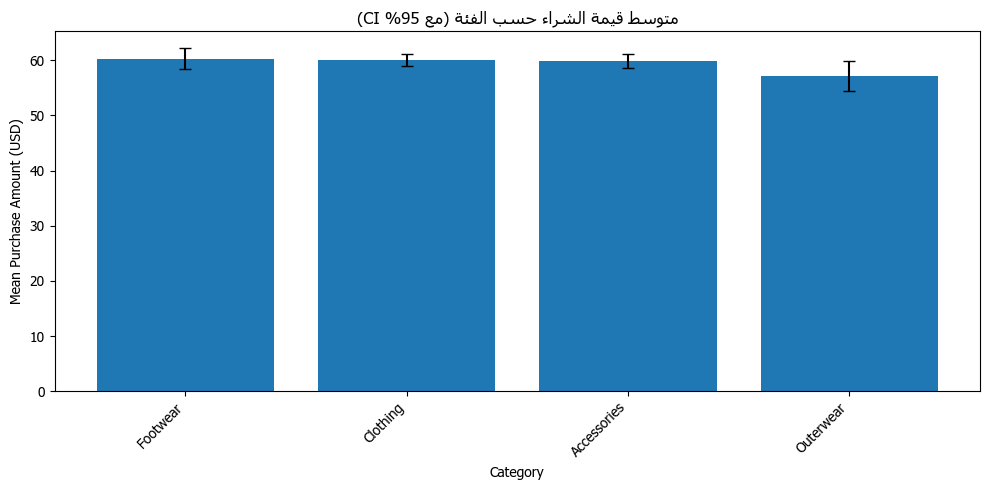

   Category    N  Mean   Std   SE  CI95
   Footwear  599 60.26 23.64 0.97  1.89
   Clothing 1737 60.03 23.79 0.57  1.12
Accessories 1240 59.84 23.30 0.66  1.30
  Outerwear  324 57.17 24.59 1.37  2.68


In [55]:
# === [Descriptive] Mean Purchase by Category + 95% CI (bar) ===

# 1) تحميل البيانات إذا لم تكن df معرّفة
if 'df' not in globals():
    possible_paths = [
        '/mnt/data/E-Commerce-Sales-Data.enhanced_clean.csv',
        'E-Commerce-Sales-Data.enhanced_clean.csv'
    ]
    for p in possible_paths:
        if os.path.exists(p):
            df = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError(
            "لم يتم العثور على ملف البيانات. عدّل المسار داخل possible_paths ليتوافق مع جهازك."
        )

# 2) الأعمدة المطلوبة
col_y = "Purchase Amount (USD)"
col_cat = "Category"
for c in (col_cat, col_y):
    if c not in df.columns:
        raise KeyError(f"العمود غير موجود في البيانات: {c}")

# 3) التأكد أن القيم رقمية
df[col_y] = pd.to_numeric(df[col_y], errors='coerce')

# 4) تجميع: N, Mean, Std
agg = (df[[col_cat, col_y]]
       .dropna()
       #to_numeric + dropna: يضمن أن Purchase Amount (USD) رقمية ويستبعد القيم غير الصالحة قبل الحساب
       .groupby(col_cat)[col_y]
       # groupby + agg: يجمع البيانات حسب Category ويحسب N, Mean, Std لكل فئة.
       .agg(n="size", mean="mean", std="std")
       .reset_index())

# 5) الخطأ المعياري + 95% CI
agg["se"] = agg["std"] / np.sqrt(agg["n"])
agg["ci95"] = 1.96 * agg["se"]
agg["ci95"] = agg["ci95"].fillna(0)   # لو n=1

# ترتيب حسب المتوسط (يمكن تقييد العرض لأعلى 15 فئة مثلاً)
agg = agg.sort_values("mean", ascending=False)
# اختياري: عرض أعلى 15 فقط
# agg = agg.head(15)

# 6) رسم عمودي مع فواصل الثقة
plt.figure(figsize=(10, 5))
plt.bar(agg[col_cat], agg["mean"], yerr=agg["ci95"], capsize=4)
plt.title("متوسط قيمة الشراء حسب الفئة (مع 95% CI)")
plt.xlabel(col_cat)
plt.ylabel("Mean Purchase Amount (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7) ملخص رقمي (اختياري)
print(
    agg.round({"mean": 2, "std": 2, "se": 2, "ci95": 2})
       .rename(columns={"n": "N", "mean": "Mean", "std": "Std", "se": "SE", "ci95": "CI95"})
       .to_string(index=False)
)


### 4.2 ما توزيع Quantity لكل Category؟

<Figure size 1000x600 with 0 Axes>

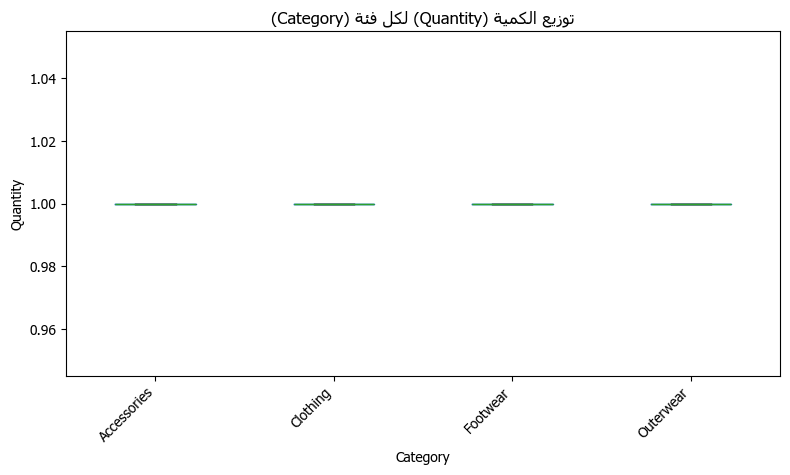

In [56]:
# === [Descriptive] Distribution of Quantity by Category (Boxplot) ===


col_y = "Quantity"
col_cat = "Category"

# إزالة القيم الفارغة
df_clean = df[[col_cat, col_y]].dropna()

# تجهيز الترتيب حسب تكرار الفئات
order = df_clean[col_cat].value_counts().index.tolist()

# رسم Boxplot
plt.figure(figsize=(10, 6))
df_clean.boxplot(column=col_y, by=col_cat, grid=False, showfliers=False)
plt.suptitle("")  # إزالة العنوان الافتراضي
plt.title("توزيع الكمية (Quantity) لكل فئة (Category)")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 4.3ما أكثر Location من حيث عدد الطلبات؟

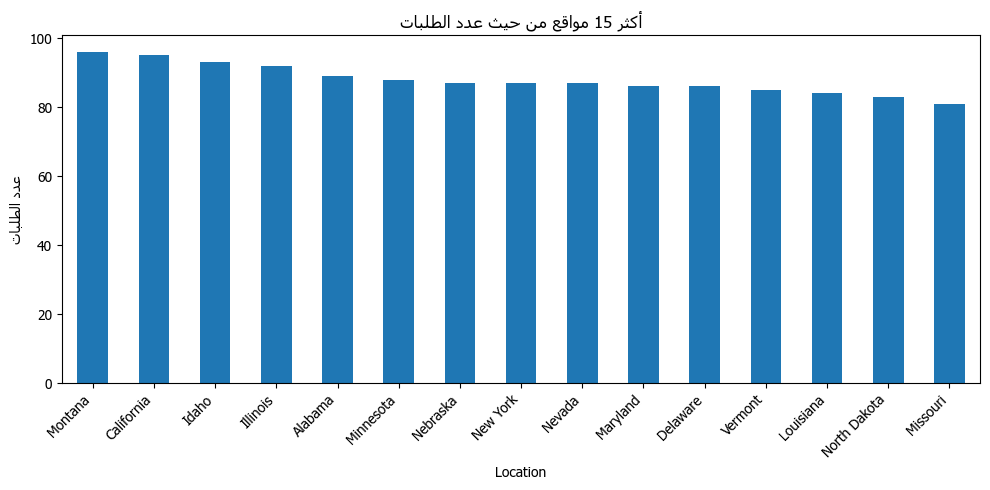

أكثر Location من حيث عدد الطلبات هو: Montana (96 طلب).


In [57]:
# === [Descriptive] Top Location by Number of Orders ===


col_loc = "Location"

# حساب عدد الطلبات لكل Location
counts = df[col_loc].value_counts()

# عرض أعلى 15 موقع
top_n = 15
counts.head(top_n).plot(kind="bar", figsize=(10,5))
plt.title(f"أكثر {top_n} مواقع من حيث عدد الطلبات")
plt.xlabel("Location")
plt.ylabel("عدد الطلبات")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# طباعة الموقع الأعلى
top_location = counts.idxmax()
top_count = counts.max()
print(f"أكثر Location من حيث عدد الطلبات هو: {top_location} ({top_count} طلب).")


### 4.4 ما أكثر Shipping Type استخدامًا؟

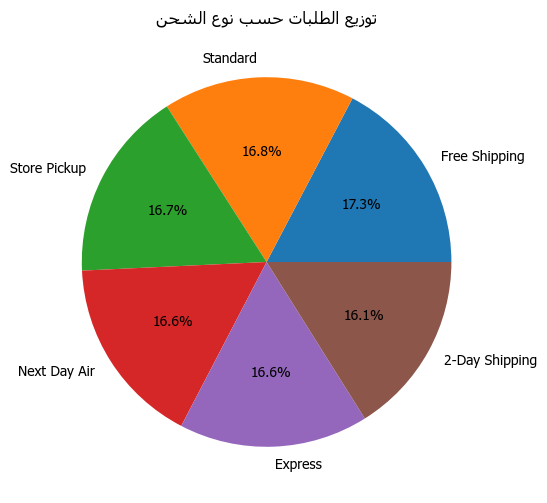

أكثر نوع شحن استخدامًا هو: Free Shipping (675 طلب = 17.3%).


In [58]:
# === [Descriptive] Most Used Shipping Type ===


col_ship = "Shipping Type"

# حساب عدد الطلبات لكل نوع شحن
ship_counts = df[col_ship].value_counts()

# رسم Pie chart لتوضيح النسب
ship_counts.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("توزيع الطلبات حسب نوع الشحن")
plt.ylabel("")
plt.show()

# طباعة النوع الأكثر استخدامًا
top_ship = ship_counts.idxmax()
top_count = ship_counts.max()
top_ratio = top_count / ship_counts.sum() * 100
print(f"أكثر نوع شحن استخدامًا هو: {top_ship} ({top_count} طلب = {top_ratio:.1f}%).")


4.5 ما توزيع/متوسط Review Rating حسب Category؟

تقيس سلوك الرضا/الرأي (كيف قيَّم العميل المنتج).

,Category,mean_rating,std_rating,n,se,ci95
2,Footwear,3.791,0.720,599,0.029,0.058
0,Accessories,3.769,0.715,1240,0.020,0.040
3,Outerwear,3.747,0.703,324,0.039,0.077
1,Clothing,3.723,0.718,1737,0.017,0.034


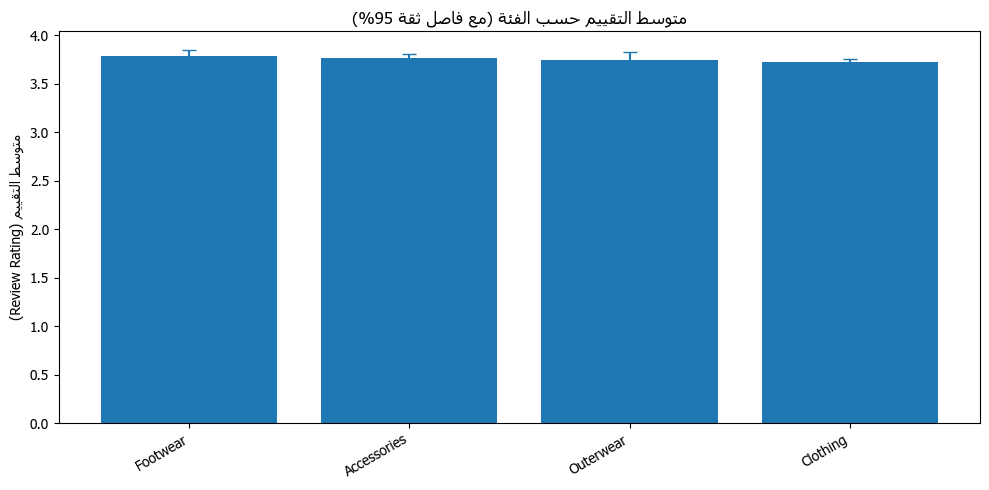

In [59]:
# === [Descriptive-1] متوسط/توزيع Review Rating حسب Category (مع CI95) ===


# (اختياري) دعم العربية إن توفّرت المكتبات
def _setup_arabic():
    try:
        import matplotlib.font_manager as fm
        # اختر أول خط عربي متاح
        pref = ['Noto Naskh Arabic', 'Amiri', 'Tahoma', 'Arial', 'DejaVu Sans']
        avail = {f.name for f in fm.fontManager.ttflist}
        for n in pref:
            if n in avail:
                plt.rcParams['font.family'] = n
                break
    except Exception:
        pass

try:
    import arabic_reshaper, bidi.algorithm as bidi
    def ar(s: str) -> str:
        return bidi.get_display(arabic_reshaper.reshape(str(s)))
except Exception:
    def ar(s: str) -> str:
        return str(s)

_setup_arabic()

def plot_rating_by_category(df: pd.DataFrame, show_table: bool = True):
    """
    ترسم متوسط التقييم Review Rating حسب الفئة Category مع فاصل ثقة 95%
    وتُرجِع DataFrame بالملخص (mean/std/n/se/ci95) لدمجه في التقارير.

    Parameters
    ----------
    df : DataFrame
        يجب أن يحتوي على الأعمدة: 'Category', 'Review Rating'
    show_table : bool
        لطباعة الملخّص في المخرجات.
    """
    needed = ["Category", "Review Rating"]
    miss = [c for c in needed if c not in df.columns]
    if miss:
        raise KeyError(f"الأعمدة الناقصة: {miss}")

    d = df[needed].dropna()
    d = d[d["Review Rating"] > 0]  # استبعاد أي قيَم غير صالحة إن وُجدت

    g = (d.groupby("Category")
           .agg(mean_rating=("Review Rating", "mean"),
                std_rating=("Review Rating", "std"),
                n=("Review Rating", "size"))
           .reset_index())

    # الخطأ المعياري وفاصل الثقة 95%
    g["se"] = g["std_rating"] / np.sqrt(g["n"]).replace(0, np.nan)
    g["ci95"] = 1.96 * g["se"]
    g = g.sort_values("mean_rating", ascending=False)

    if show_table:
        try:
            # لو شغّال داخل Jupyter/nb — يعرض كجدول جميل
            from IPython.display import display
            display(g.round(3))
        except Exception:
            print(g.round(3))

    # الرسم
    plt.figure(figsize=(10, 5))
    x = np.arange(len(g))
    plt.bar(x, g["mean_rating"])
    plt.errorbar(x, g["mean_rating"], yerr=g["ci95"], fmt='none', capsize=5)
    plt.xticks(x, [ar(c) for c in g["Category"]], rotation=30, ha='right')
    plt.ylabel(ar("متوسط التقييم (Review Rating)"))
    plt.title(ar("متوسط التقييم حسب الفئة (مع فاصل ثقة 95%)"))
    plt.tight_layout()
    plt.show()

    return g

# === مثال الاستخدام (إن لزم) ===
df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
summary = plot_rating_by_category(df)


4.6 ما أكثر طرق الدفع استخدامًا (Payment Method)؟

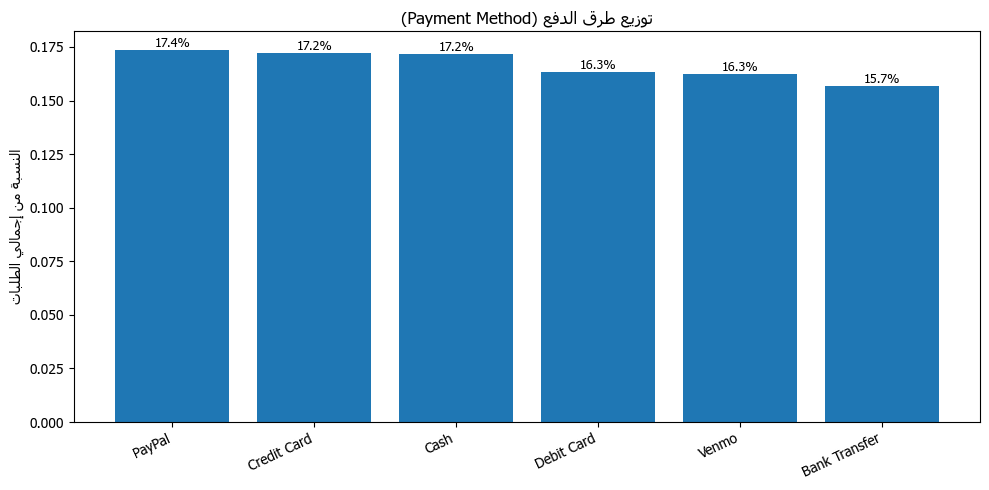

  payment_method  count     share
0         PayPal    677  0.173590
1    Credit Card    671  0.172051
2           Cash    670  0.171795
3     Debit Card    636  0.163077
4          Venmo    634  0.162564
5  Bank Transfer    612  0.156923


In [60]:
# === [Descriptive-2] توزيع طرق الدفع Payment Method (عدّ ونِسب) ===


def plot_payment_method_distribution(df: pd.DataFrame, top_n: int | None = None):
    """
    يُلخّص توزيع طرق الدفع ويرسم مخططًا عموديًا بالنِّسب.
    Parameters
    ----------
    df : DataFrame
        يجب أن يحتوي على العمود 'Payment Method'
    top_n : int | None
        لو زاد عدد الطرق كثير، يمكنك عرض أعلى N والباقي كـ 'Others'
    Returns
    -------
    summary : DataFrame
        أعمدة: payment_method, count, share
    """
    col = "Payment Method"
    if col not in df.columns:
        raise KeyError(f"العمود غير موجود: {col}")

    # تنظيف بسيط
    x = (df[[col]]
         .dropna()
         .assign(**{col: lambda d: d[col].astype(str).str.strip()}))

    # تجميع
    s = (x[col].value_counts(dropna=False)
               .rename_axis("payment_method")
               .reset_index(name="count"))

    total = s["count"].sum()
    s["share"] = s["count"] / total

    # تقليص إلى Top-N إن لزم
    if top_n is not None and len(s) > top_n:
        top = s.iloc[:top_n].copy()
        rest_count = s.iloc[top_n:]["count"].sum()
        if rest_count > 0:
            top.loc[len(top)] = ["Others", rest_count, rest_count / total]
        s = top

    # ترتيب
    s = s.sort_values("count", ascending=False).reset_index(drop=True)

    # الرسم
    plt.figure(figsize=(10, 5))
    xs = np.arange(len(s))
    plt.bar(xs, s["share"])  # نسب
    plt.xticks(xs, [ar(v) for v in s["payment_method"]], rotation=25, ha='right')
    plt.ylabel(ar("النسبة من إجمالي الطلبات"))
    plt.title(ar("توزيع طرق الدفع (Payment Method)"))
    # تسميات نسب فوق الأعمدة
    for i, v in enumerate(s["share"]):
        plt.text(i, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    return s

# === مثال الاستخدام ===
summary_pm = plot_payment_method_distribution(df, top_n=None)
print(summary_pm)


4.7 ما أكثر الألوان (Color) مبيعًا؟

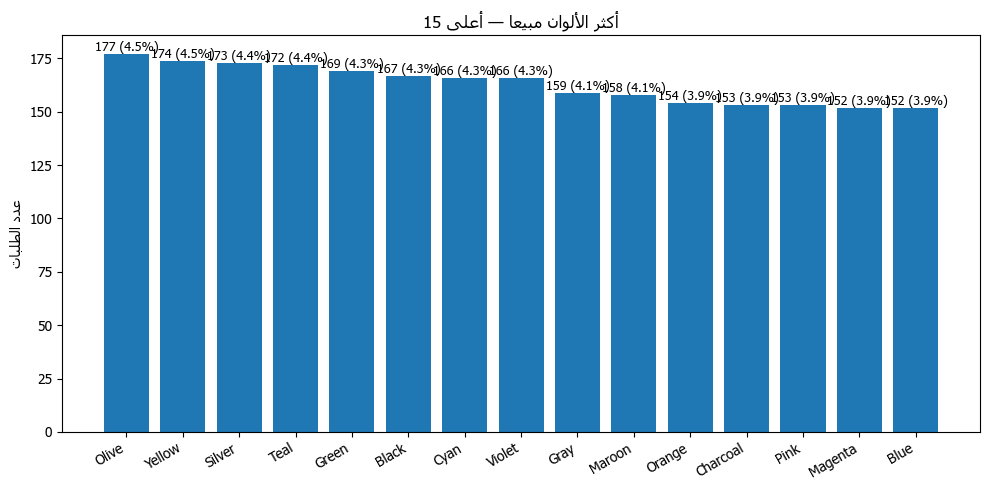

    Color  count     share
0   Olive    177  0.045385
1  Yellow    174  0.044615
2  Silver    173  0.044359
3    Teal    172  0.044103
4   Green    169  0.043333


In [61]:
# === [Descriptive-3] أكثر الألوان مبيعًا (Color) — عدّ ونِسب مع رسم ===



def plot_top_colors(df: pd.DataFrame, top_n: int = 15):
    """
    يُرجع جدولًا بأكثر الألوان مبيعًا (count/percent) ويرسم مخططًا عموديًا لأعلى N.
    Parameters
    ----------
    df : DataFrame يحوي العمود 'Color'
    top_n : int عدد الألوان المعروضة في الرسم
    Returns
    -------
    summary : DataFrame بأعمدة ['Color','count','share']
    """
    col = "Color"
    if col not in df.columns:
        raise KeyError(f"العمود غير موجود: {col}")

    x = (df[[col]].dropna()
                    .assign(**{col: lambda d: d[col].astype(str).str.strip()}))

    s = (x[col].value_counts()
                 .rename_axis("Color")
                 .reset_index(name="count"))
    s["share"] = s["count"] / s["count"].sum()
    s_top = s.head(top_n).copy()

    # الرسم
    plt.figure(figsize=(10, 5))
    xs = np.arange(len(s_top))
    plt.bar(xs, s_top["count"])
    plt.xticks(xs, [ar(v) for v in s_top["Color"]], rotation=30, ha='right')
    plt.ylabel(ar("عدد الطلبات"))
    plt.title(ar(f"أكثر الألوان مبيعًا — أعلى {top_n}"))
    # تسميات العد والنسبة فوق الأعمدة
    for i, (cnt, p) in enumerate(zip(s_top["count"], s_top["share"])):
        plt.text(i, cnt, f"{cnt} ({p*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    return s

# === مثال الاستخدام ===
summary_colors = plot_top_colors(df, top_n=15)
print(summary_colors.head())


4.8 ما أكثر المقاسات (Size) شيوعًا في الملابس؟

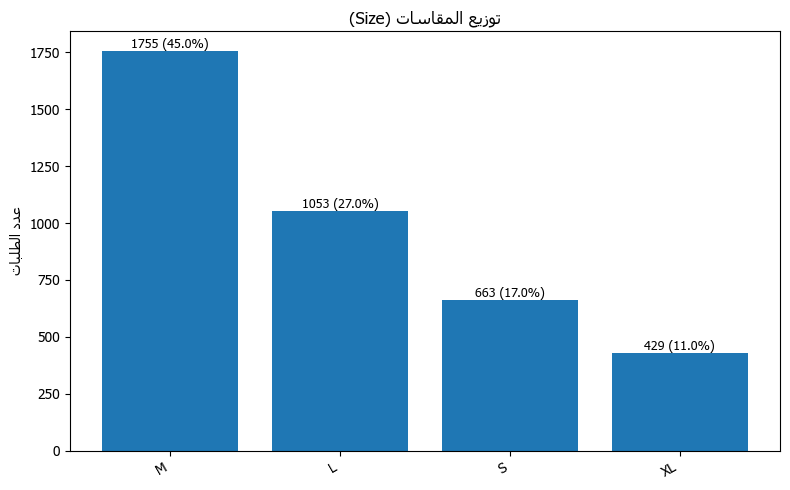

  Size  count  share
0    M   1755   0.45
1    L   1053   0.27
2    S    663   0.17
3   XL    429   0.11


In [62]:
# === [Descriptive-4] أكثر المقاسات شيوعًا (Size) — عدّ ونِسب مع رسم ===


def plot_size_distribution(df: pd.DataFrame):
    """
    يُرجع جدولًا بتوزيع المقاسات (Size) ويرسم مخططًا عموديًا.
    Parameters
    ----------
    df : DataFrame يحوي العمود 'Size'
    Returns
    -------
    summary : DataFrame بأعمدة ['Size','count','share']
    """
    col = "Size"
    if col not in df.columns:
        raise KeyError(f"العمود غير موجود: {col}")

    x = (df[[col]].dropna()
                    .assign(**{col: lambda d: d[col].astype(str).str.strip()}))

    s = (x[col].value_counts()
                 .rename_axis("Size")
                 .reset_index(name="count"))
    s["share"] = s["count"] / s["count"].sum()

    # الرسم
    plt.figure(figsize=(8, 5))
    xs = np.arange(len(s))
    plt.bar(xs, s["count"])
    plt.xticks(xs, [ar(v) for v in s["Size"]], rotation=30, ha='right')
    plt.ylabel(ar("عدد الطلبات"))
    plt.title(ar("توزيع المقاسات (Size)"))
    for i, (cnt, p) in enumerate(zip(s["count"], s["share"])):
        plt.text(i, cnt, f"{cnt} ({p*100:.1f}%)", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()

    return s

# === مثال الاستخدام ===
df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
summary_sizes = plot_size_distribution(df)
print(summary_sizes)


4.9 "ما توزيع أعمار العملاء؟"

تعرف الفئات العمرية الأكثر ظهورًا.

KeyboardInterrupt: 

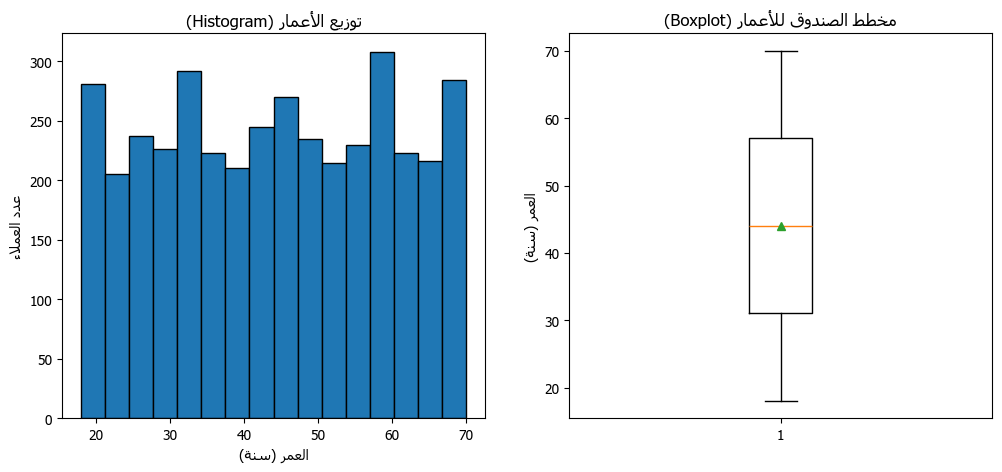

In [63]:
# === [Descriptive] توزيع الأعمار Age Distribution (Histogram + Boxplot + Summary) ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (اختياري) دعم خطوط عربية إن وُجدت
def _setup_arabic():
    try:
        import matplotlib.font_manager as fm
        pref = ['Noto Naskh Arabic', 'Amiri', 'Tahoma', 'Arial', 'DejaVu Sans']
        avail = {f.name for f in fm.fontManager.ttflist}
        for n in pref:
            if n in avail:
                plt.rcParams['font.family'] = n
                break
    except Exception:
        pass

_setup_arabic()
plt.rcParams['figure.figsize'] = (10, 5)

# 1) تحميل البيانات إذا ما كان df موجود
if 'df' not in globals():
    possible_paths = [
        '/mnt/data/E-Commerce-Sales-Data.enhanced_clean.csv',
        'E-Commerce-Sales-Data.enhanced_clean.csv'
    ]
    for p in possible_paths:
        if os.path.exists(p):
            df = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError("عدّل المسار داخل possible_paths ليتوافق مع جهازك.")

# 2) التأكد من وجود عمود Age وتحويله لرقمي
col_age = "Age"
if col_age not in df.columns:
    raise KeyError(f"العمود غير موجود في البيانات: {col_age}")

age = pd.to_numeric(df[col_age], errors='coerce').dropna()
if age.empty:
    raise ValueError("لا توجد قيم صالحة في عمود Age بعد التحويل الرقمي.")

# 3) اختيار عدد الصناديق (bins) بطريقة Freedman–Diaconis لمواؤمة التوزيع
q1, q3 = np.percentile(age, [25, 75])
iqr = q3 - q1
bin_width = (2 * iqr) / np.cbrt(age.size) if iqr > 0 else max(1, int(np.sqrt(age.size)))
bins = max(5, int(np.ceil((age.max() - age.min()) / bin_width))) if bin_width else 10

# 4) الرسم: Histogram + Boxplot
fig = plt.figure(figsize=(12, 5))

# 4.a Histogram
plt.subplot(1, 2, 1)
plt.hist(age, bins=bins, edgecolor='black')
plt.title("توزيع الأعمار (Histogram)")
plt.xlabel("العمر (سنة)")
plt.ylabel("عدد العملاء")

# 4.b Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(age, vert=True, showmeans=True, meanline=False)
plt.title("مخطط الصندوق للأعمار (Boxplot)")
plt.ylabel("العمر (سنة)")
plt.tight_layout()
plt.show()

# 5) جدول ملخص وصفي
summary = age.describe(percentiles=[0.25, 0.5, 0.75]).rename({
    "count": "N",
    "mean": "Mean",
    "std": "Std",
    "min": "Min",
    "25%": "Q1",
    "50%": "Median",
    "75%": "Q3",
    "max": "Max"
})
print("\nملخص وصفي لعمر العملاء:")
print(summary.to_frame().T.round(2).to_string(index=False))

# 6) (اختياري) توزيع الفئات العمرية AgeGroup إن وُجدت
if "AgeGroup" in df.columns:
    agegroup_counts = (df["AgeGroup"].astype(str)
                       .value_counts()
                       .rename_axis("AgeGroup")
                       .reset_index(name="Count"))
    agegroup_counts["Percent"] = (agegroup_counts["Count"] / agegroup_counts["Count"].sum() * 100).round(2)
    print("\nتوزيع الفئات العمرية (AgeGroup):")
    print(agegroup_counts.to_string(index=False))


4.10 ما متوسط عدد المشتريات السابقة (Previous Purchases) حسب Category؟

 “ما متوسط عدد المشتريات السابقة (Previous Purchases) للعملاء بحسب الفئة (Category) التي يشترونها الآن؟”

هو إجمالي عدد المرات التي اشترى فيها العميل سابقًا (بشكل عام، من أي فئة)، قبل عملية الشراء الحالية.

إذًا السؤال الذي يجيب عنه الرسم:
“هل العملاء الذين يشترون هذه الفئة الآن لديهم تاريخ شراء أكبر/أصغر من غيرهم؟”
والإجابة: كلهم تقريبًا متشابهون (~25).

,Category,n,mean,std,se,ci95
0,Accessories,1240,25.73,14.54,0.41,0.81
2,Footwear,599,25.23,14.18,0.58,1.14
1,Clothing,1737,25.20,14.31,0.34,0.67
3,Outerwear,324,24.96,15.32,0.85,1.67


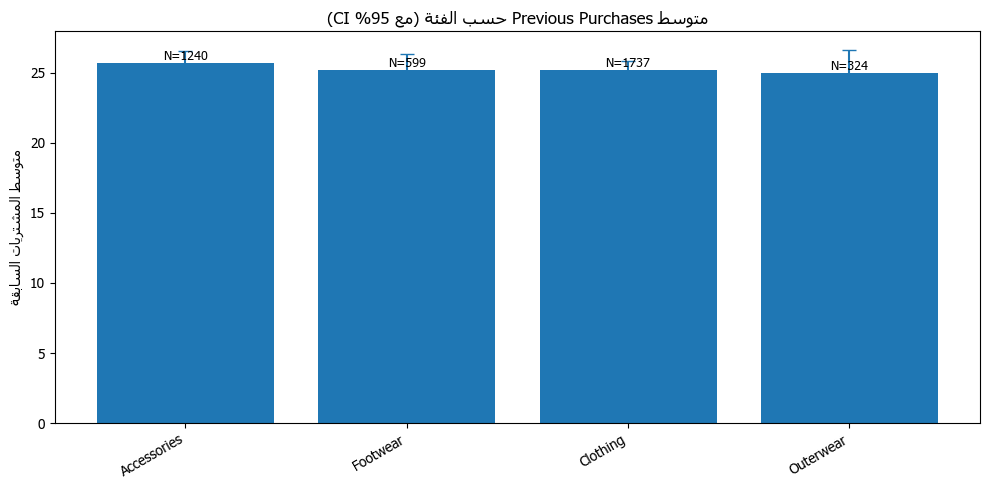

      Category     n   mean    std    se  ci95
0  Accessories  1240  25.73  14.54  0.41  0.81
2     Footwear   599  25.23  14.18  0.58  1.14
1     Clothing  1737  25.20  14.31  0.34  0.67
3    Outerwear   324  24.96  15.32  0.85  1.67


In [ ]:


# بديل بسيط لو دالة ar غير معرّفة
try:
    ar
except NameError:
    def ar(s): 
        return str(s)

def plot_prev_purchases_by_category(df: pd.DataFrame, show_table: bool = True):
    """
    يحسب ويعرض متوسط عدد المشتريات السابقة لكل فئة (Category)
    مع الانحراف المعياري، الخطأ المعياري، وفاصل الثقة 95%.
    
    Returns
    -------
    summary : DataFrame بأعمدة ['Category','mean','std','n','se','ci95']
    """
    needed = ["Category", "Previous Purchases"]
    miss = [c for c in needed if c not in df.columns]
    if miss:
        raise KeyError(f"الأعمدة الناقصة: {miss}")

    d = df[needed].copy()
    d["Previous Purchases"] = pd.to_numeric(d["Previous Purchases"], errors="coerce")
    d = d.dropna()

    g = (d.groupby("Category")["Previous Purchases"]
           .agg(n="size", mean="mean", std="std")
           .reset_index())

    g["se"] = g["std"] / np.sqrt(g["n"])
    g["ci95"] = 1.96 * g["se"]
    g = g.sort_values("mean", ascending=False)

    if show_table:
        try:
            from IPython.display import display
            display(g.round(2))
        except Exception:
            print(g.round(2).to_string(index=False))

    # رسم Bar مع أشرطة الثقة
    plt.figure(figsize=(10, 5))
    x = np.arange(len(g))
    plt.bar(x, g["mean"])
    plt.errorbar(x, g["mean"], yerr=g["ci95"], fmt="none", capsize=5)
    plt.xticks(x, [ar(c) for c in g["Category"]], rotation=30, ha="right")
    plt.ylabel(ar("متوسط المشتريات السابقة"))
    plt.title(ar("متوسط Previous Purchases حسب الفئة (مع 95% CI)"))

    # توضيح N فوق كل عمود
    for i, (m, n) in enumerate(zip(g["mean"], g["n"])):
        plt.text(i, m, f"N={int(n)}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    return g

# === مثال استخدام ===
# df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
summary_prev = plot_prev_purchases_by_category(df)
print(summary_prev.round(2))


### 5 فرضيات تشخيصة 


5.1 هل انخفاض الربح مرتبط بارتفاع الخصومات؟ (بديل الربح = سعر الوحدة)

متوسط سعر الوحدة بدون خصم: 60.130454340980656
متوسط سعر الوحدة مع خصم  : 59.27906976744186
اختبار Mann-Whitney: الاحصائية=1903139.0, p-value=0.2607


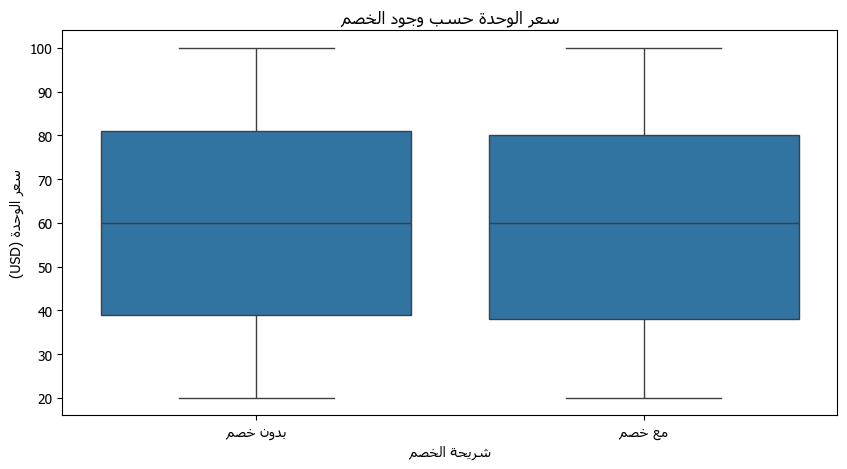

In [64]:
import seaborn as sns
from scipy.stats import mannwhitneyu

# تحويل علم الخصم إلى 0/1 بشكل مرن
if 'Discount_Flag' in df.columns:
    df['_disc_flag'] = df['Discount_Flag'].astype(int)
elif 'Discount Applied' in df.columns:
    df['_disc_flag'] = df['Discount Applied'].astype(str).str.strip().str.lower().map({'yes':1,'no':0})
else:
    raise ValueError("لم أجد عمودًا للخصم (جرّب Discount_Flag أو Discount Applied).")

# حساب سعر الوحدة كمؤشر للربح/الهامش
df['_unit_price'] = df['Purchase Amount (USD)'] / df['Quantity']
tmp = df.dropna(subset=['_unit_price','_disc_flag']).copy()

# مقارنة المجموعتين (بدون فرضية التوزيع الطبيعي)
g0 = tmp.loc[tmp['_disc_flag']==0, '_unit_price']  # بدون خصم
g1 = tmp.loc[tmp['_disc_flag']==1, '_unit_price']  # مع خصم
stat, p = mannwhitneyu(g0, g1, alternative='two-sided')

print("متوسط سعر الوحدة بدون خصم:", g0.mean())
print("متوسط سعر الوحدة مع خصم  :", g1.mean())
print(f"اختبار Mann-Whitney: الاحصائية={stat:.1f}, p-value={p:.4f}")

# رسم توضيحي
sns.boxplot(data=tmp, x='_disc_flag', y='_unit_price')
plt.xticks([0,1], ['بدون خصم','مع خصم'])
plt.xlabel('شريحة الخصم'); plt.ylabel('سعر الوحدة (USD)')
plt.title('سعر الوحدة حسب وجود الخصم')
plt.show()


5.2 هل تختلف أيام الشحن المتوقعة بين المناطق (Location)؟

قياس “أيام الشحن المتوقعة” تمَّ بشكل تقريبي عبر تحويل نوع الشحن إلى أيام (Store Pickup=0, Next Day=1, …).

لا يوجد دليل معنوي على أن المنطقة تؤثر على أيام الشحن المتوقعة (بحسب هذا المؤشر التقريبي).

متوسط الأيام المتوقعة حسب المنطقة (أول 15):
 Location
Alabama          1.865169
Connecticut      1.923077
Oklahoma         2.000000
Indiana          2.075949
Wyoming          2.084507
New Hampshire    2.140845
Massachusetts    2.152778
Iowa             2.159420
Illinois         2.163043
Hawaii           2.169231
South Dakota     2.171429
Nebraska         2.206897
Ohio             2.207792
Rhode Island     2.222222
Colorado         2.226667
Name: _expected_days, dtype: float64

Kruskal-Wallis عبر المناطق: H=59.54, p-value=0.1440


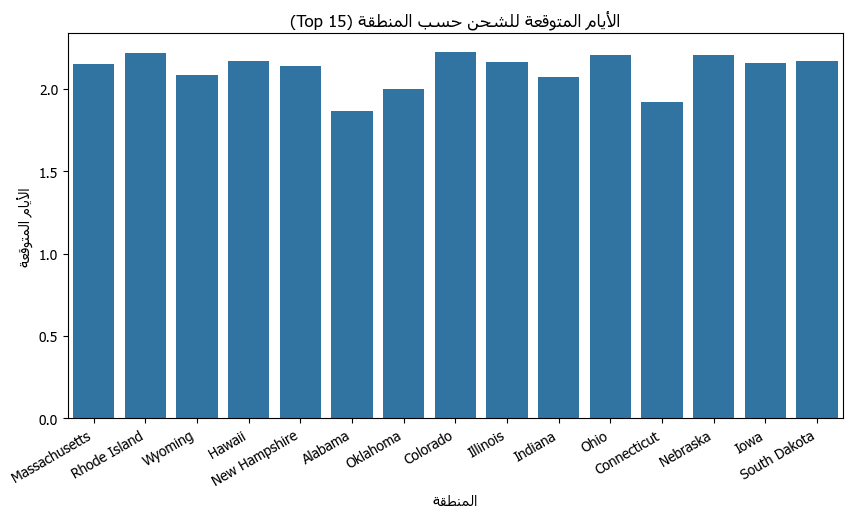

In [65]:
# فرضية: زمن الشحن المتوقع يختلف حسب المنطقة (بديل للتأخر الفعلي عند غياب تواريخ الطلب/الشحن)
# يعتمد على: 'Shipping Type', 'Location'

import seaborn as sns
from scipy.stats import kruskal

assert 'Shipping Type' in df.columns and 'Location' in df.columns, "يلزم وجود الأعمدة: Shipping Type و Location."

# تعيين عدد أيام متوقع لكل نوع شحن (يمكن تعديله حسب سياستك)
ship_days_map = {
    'Store Pickup': 0,
    'Next Day Air': 1,
    '2-Day Shipping': 2,
    'Express': 2,
    'Standard': 4,
    'Free Shipping': 5
}
tmp = df[['Shipping Type','Location']].copy()
tmp['_expected_days'] = tmp['Shipping Type'].map(ship_days_map)

# تلخيص حسب المنطقة
summary = tmp.groupby('Location', observed=True)['_expected_days'].mean().sort_values()
print("متوسط الأيام المتوقعة حسب المنطقة (أول 15):\n", summary.head(15))

# اختبار فروق المجموعات (غير معلمي)
groups = [g['_expected_days'].dropna().values for _, g in tmp.groupby('Location')]
if len(groups) >= 2:
    stat, p = kruskal(*groups)
    print(f"\nKruskal-Wallis عبر المناطق: H={stat:.2f}, p-value={p:.4f}")

# رسم
top_locs = summary.index[:15]  # أول 15 منطقة
sns.barplot(data=tmp[tmp['Location'].isin(top_locs)],
            x='Location', y='_expected_days', estimator=np.mean, errorbar=None)
plt.xticks(rotation=30, ha='right')
plt.xlabel('المنطقة'); plt.ylabel('الأيام المتوقعة')
plt.title('الأيام المتوقعة للشحن حسب المنطقة (Top 15)')
plt.show()


5.3 هل نسبة الإرجاع أعلى مع خصم مرتفع؟ (بديل الإرجاع = تقييم منخفض ≤ 3)

In [ ]:
# فرضية: وجود خصم يرتبط بارتفاع "علامات عدم الرضا" (نائب عن الإرجاع) باستخدام تقييم ≤ 3
# يعتمد على: 'Review Rating' وعمود خصم ('Discount_Flag' أو 'Discount Applied')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# عمود الخصم (كما في الخلية الأولى)
if '_disc_flag' not in df.columns:
    if 'Discount_Flag' in df.columns:
        df['_disc_flag'] = df['Discount_Flag'].astype(int)
    elif 'Discount Applied' in df.columns:
        df['_disc_flag'] = df['Discount Applied'].astype(str).str.strip().str.lower().map({'yes':1,'no':0})
    else:
        raise ValueError("لم أجد عمودًا للخصم.")

assert 'Review Rating' in df.columns, "لم أجد عمود Review Rating."

# تعريف "عدم الرضا" كنائب للإرجاع
df['_low_rating'] = (df['Review Rating'] <= 3.0).astype(int)

# معدلات "عدم الرضا" حسب الخصم
rate = df.groupby('_disc_flag', observed=True)['_low_rating'].mean().rename({0:'بدون خصم',1:'مع خصم'})
print("نسبة التقييم المنخفض (≤3) حسب وجود الخصم:\n", rate)

# اختبار كاي-تربيع للاستقلال
ct = pd.crosstab(df['_disc_flag'], df['_low_rating'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f"\nChi-square: χ²={chi2:.3f}, p-value={p:.4f}, dof={dof}")
print("الجدول التقاطعي:\n", ct)

# رسم
sns.barplot(x=['بدون خصم','مع خصم'], y=rate.values)
plt.ylabel('نسبة تقييم منخفض (≤3)')
plt.title('نسبة عدم الرضا حسب وجود الخصم')
plt.show()


5.4 هل العملاء ذوي المشتريات السابقة الكثيرة (Previous Purchases) يعطون تقييمًا أعلى (Review Rating)؟

الفكرة:

نقسم العملاء إلى شرائح بناءً على المشتريات السابقة (مثلاً: قليلة/متوسطة/عالية).

نقارن متوسط التقييمات بينهم باستخدام جدول + رسم.

ممكن نعمل اختبار إحصائي (ANOVA أو Kruskal-Wallis) لو نحب نثبت دلالة الفرق.

In [ ]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import f_oneway, kruskal

# --- Arabic helper (خفيف) ---
def _setup_ar():
    try:
        import matplotlib.font_manager as fm
        for n in ['Noto Naskh Arabic','Amiri','Arial','Tahoma','DejaVu Sans']:
            if n in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = n; break
        plt.rcParams['axes.unicode_minus'] = False
    except: pass
_setup_ar()
_AR = re.compile(r'[\u0600-\u06FF]')
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    def ar(s): s=str(s); return get_display(arabic_reshaper.reshape(s)) if _AR.search(s) else s
except:
    def ar(s): return str(s)

# --- Diagnostic: Previous Purchases → Review Rating ---
def prev_purchases_vs_rating(df, bins=(0,2,5,10,np.inf),
                             labels=("Low(0-2)","Medium(3-5)","High(6-10)","Very High(>10)"),
                             use_kruskal=False):
    for c in ("Previous Purchases","Review Rating"):
        if c not in df.columns: raise KeyError(f"missing col {c}")
    d = df[["Previous Purchases","Review Rating"]].dropna().copy()
    d = d[d["Review Rating"] > 0]
    d["Purch_Group"] = pd.cut(d["Previous Purchases"], bins=bins, labels=labels, right=True, include_lowest=True)

    g = (d.groupby("Purch_Group", observed=False)["Review Rating"]
           .agg(count="size", mean="mean", std="std").reset_index())
    g["se"] = np.where(g["count"]>1, g["std"]/np.sqrt(g["count"]), np.nan)
    g["ci95"] = 1.96*g["se"]

    groups = [v["Review Rating"].values for _, v in d.groupby("Purch_Group", observed=False) if len(v)]
    if len(groups)>=2:
        stat,p = (kruskal if use_kruskal else f_oneway)(*groups)
        test = "Kruskal" if use_kruskal else "ANOVA"
    else:
        stat=p=np.nan; test="NA"

    plt.figure(figsize=(8,5))
    x = np.arange(len(g))
    plt.bar(x, g["mean"], yerr=g["ci95"], capsize=5)
    plt.xticks(x, [ar(v) for v in g["Purch_Group"].astype(str)])
    plt.ylabel(ar("متوسط التقييم (Review Rating)"))
    plt.title(ar("متوسط التقييم حسب المشتريات السابقة (CI95)"))
    for i,m in enumerate(g["mean"]):
        if pd.notna(m): plt.text(i, m, f"{m:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

    return g, {"test": test, "stat": stat, "p": p}

# مثال:
df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
summary, test = prev_purchases_vs_rating(df)
print(summary.round(3)); print(test)


5.5 هل الاشتراك (Subscription Status) يفسّر زيادة المشتريات (Purchase Amount أو Quantity)؟

الفكرة:

نقارن بين مجموعتين:

العملاء المشتركين (Subscription Status = Yes).

العملاء غير المشتركين (Subscription Status = No).

نشوف إذا في فرق معنوي في:

متوسط قيمة الشراء (Purchase Amount (USD)).

أو متوسط الكمية (Quantity).

نستخدم اختبار t-test للمجموعتين + رسم صندوقي (Boxplot) للتوضيح.

In [ ]:
# === [Diagnostic-2] Subscription Status → Purchases (t-test + Boxplot) ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def subscription_vs_purchases(df, target="Purchase Amount (USD)"):
    if "Subscription Status" not in df.columns or target not in df.columns:
        raise KeyError("الأعمدة المطلوبة غير موجودة")

    d = df[["Subscription Status", target]].dropna().copy()
    d[target] = pd.to_numeric(d[target], errors="coerce")
    d = d.dropna()

    # تقسيم المجموعتين
    subs = d[d["Subscription Status"].str.lower().str.contains("yes")][target]
    nons = d[d["Subscription Status"].str.lower().str.contains("no")][target]

    # اختبار t-test
    stat, p = ttest_ind(subs, nons, equal_var=False)
    print(f"T-test: stat={stat:.3f}, p={p:.5f}")
    print("✅ فرق معنوي" if p<0.05 else "⚠️ لا يوجد فرق معنوي واضح")

    # جدول ملخص
    summary = d.groupby("Subscription Status")[target].agg(["count","mean","std"]).round(3)
    print(summary)

    # الرسم
    plt.figure(figsize=(6,5))
    d.boxplot(column=target, by="Subscription Status", grid=False)
    plt.title(f"{target} حسب Subscription Status")
    plt.suptitle("")
    plt.ylabel(target)
    plt.show()

    return summary, {"t_stat": stat, "p": p}

# === مثال الاستخدام ===
summary, test = subscription_vs_purchases(df, target="Purchase Amount (USD)")
summary_q, test_q = subscription_vs_purchases(df, target="Quantity")


الفرضيات التنبؤية (Predictive)

هل يمكن التنبؤ بقيمة الطلب (Purchase Amount (USD)) من:

الكمية (Quantity)

الخصم (Discount Applied)

الفئة (Category)

In [ ]:
# ==== Arabic helper (مرة واحدة في مشروعك) ====
import re, matplotlib.pyplot as plt
def setup_arabic():
    try:
        import matplotlib.font_manager as fm
        for n in ['Noto Naskh Arabic','Amiri','Arial','Tahoma','DejaVu Sans']:
            if n in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = n; break
        plt.rcParams['axes.unicode_minus'] = False
    except: pass
_AR = re.compile(r'[\u0600-\u06FF]')
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    def ar(s): s=str(s); return get_display(arabic_reshaper.reshape(s)) if _AR.search(s) else s
except:
    def ar(s): return str(s)
setup_arabic()

# ==== [Predictive-1] التنبؤ بقيمة الطلب من (Quantity + Discount + Category) ====
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def _to_num01(s):
    x = str(s).strip().lower()
    if x in ("yes","y","true","1"):  return 1
    if x in ("no","n","false","0",""): return 0
    try: return float(s)
    except: return np.nan

def predict_purchase_amount(df):
    target = "Purchase Amount (USD)"
    req = [target, "Quantity", "Category"]
    for c in req:
        if c not in df.columns: raise KeyError(f"العمود {c} غير موجود")

    d = df[[target, "Quantity", "Category",
            "Discount Applied" if "Discount Applied" in df.columns else None,
            "Discount_Flag" if "Discount_Flag" in df.columns else None]].copy()

    # عمود خصم رقمي موحّد
    d["Discount_Numeric"] = np.nan
    if "Discount Applied" in d.columns and "Discount Applied" in df:
        d["Discount_Numeric"] = d["Discount Applied"].map(_to_num01)
    if d["Discount_Numeric"].isna().mean() > 0.5 and "Discount_Flag" in d.columns:
        d["Discount_Numeric"] = d["Discount_Flag"]

    d = d.dropna(subset=[target, "Quantity", "Category"]).copy()
    d["Discount_Numeric"] = d["Discount_Numeric"].fillna(0)

    # One-Hot للفئة
    d = pd.get_dummies(d, columns=["Category"], drop_first=True)

    X = d.drop(columns=[target] + [c for c in ["Discount Applied","Discount_Flag"] if c in d.columns])
    y = d[target].astype(float)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression().fit(Xtr, ytr)
    ypred = model.predict(Xte)

    mae = mean_absolute_error(yte, ypred)
    r2  = r2_score(yte, ypred)
    print(f"MAE = {mae:.3f}")
    print(f"R²  = {r2:.3f}")
    print("Features:", list(X.columns))

    # رسم بعناوين عربية صحيحة
    plt.figure(figsize=(6,6))
    plt.scatter(yte, ypred, alpha=0.5)
    mn, mx = float(min(yte.min(), ypred.min())), float(max(yte.max(), ypred.max()))
    plt.plot([mn, mx], [mn, mx], 'r--')
    plt.xlabel(ar("القيم الحقيقية"))
    plt.ylabel(ar("القيم المتوقعة"))
    plt.title(ar("المقارنة بين القيم الحقيقية والمتوقعة"))
    plt.tight_layout(); plt.show()

    return model, mae, r2, list(X.columns)

# === مثال سريع ===
df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
model, mae, r2, feats = predict_purchase_amount(df)


[Predictive-2] التنبؤ بانخفاض التقييم Review Rating ≤ 3 (تصنيف ثنائي)

In [ ]:
# ==== [Predictive-2] Low Rating (<=3) Classification ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score

# استخدم ar() إن كانت مُعرّفة؛ وإلا وفّر بديل بسيط
try:
    ar
except NameError:
    def ar(s): return str(s)

def predict_low_rating(df: pd.DataFrame):
    # الهدف: 1 إذا التقييم <=3 ، وإلا 0
    target_col = "Review Rating"
    if target_col not in df.columns:
        raise KeyError("لا يوجد العمود 'Review Rating'")

    # اختر ميزات مفيدة ومتوفرة
    num_feats  = ["Age", "Quantity", "Discount_Flag", "Promo_Flag", "Sub_Flag", "Previous Purchases"]
    cat_feats  = ["Category", "Season", "Shipping Type", "Payment Method", "Gender", "Location"]

    use_cols = [c for c in num_feats + cat_feats + [target_col] if c in df.columns]
    d = df[use_cols].dropna().copy()
    d["y"] = (d[target_col] <= 3).astype(int)

    X = d.drop(columns=[target_col, "y"])
    y = d["y"].values

    # أعمدة رقمية/صنفية الفعلية بعد التقاطع مع الداتا
    num_feats  = [c for c in num_feats if c in X.columns]
    cat_feats  = [c for c in cat_feats if c in X.columns]

    # محوّل الأعمدة
    pre = ColumnTransformer([
        ("num", StandardScaler(with_mean=False), num_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
    ])

    # نموذج لوجستي مع موازنة الفئات
    clf = Pipeline(steps=[
        ("pre", pre),
        ("lr", LogisticRegression(max_iter=200, class_weight="balanced"))
    ])

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    clf.fit(Xtr, ytr)

    # توقعات واحتمالات
    ypred = clf.predict(Xte)
    yproba = clf.predict_proba(Xte)[:, 1]

    # تقارير
    print(classification_report(yte, ypred, digits=3))
    auc = roc_auc_score(yte, yproba)
    print(f"ROC-AUC = {auc:.3f}")

    # مصفوفة الالتباس
    cm = confusion_matrix(yte, ypred)
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(ar("مصفوفة الالتباس"))
    plt.xlabel(ar("المتوقّع")); plt.ylabel(ar("الحقيقي"))
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.xticks([0,1],[ar("مرتفع (>3)"), ar("منخفض (≤3)")])
    plt.yticks([0,1],[ar("مرتفع (>3)"), ar("منخفض (≤3)")])
    plt.tight_layout(); plt.show()

    # ROC Curve
    plt.figure(figsize=(5,5))
    RocCurveDisplay.from_predictions(yte, yproba)
    plt.title(ar("منحنى ROC لتصنيف التقييم المنخفض"))
    plt.tight_layout(); plt.show()

    return clf, {"roc_auc": auc, "classes_ratio": (y.mean(), 1-y.mean())}

# === مثال الاستخدام ===
df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
model_cls, info = predict_low_rating(df)
print(info)


توجيهية (Prescriptive)

6.1 "ما أفضل طريقة شحن لكل منطقة لتعظيم جودة التجربة؟ (نقيسها بمتوسط التقييم Review Rating)"

In [ ]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

need = {'Shipping Type','Location','Review Rating'}
if not need.issubset(df.columns):
    raise ValueError(f"الأعمدة الناقصة: {list(need - set(df.columns))}")

# حساب أفضل شحن لكل ولاية
tmp = df[list(need)].dropna().copy()
rec = (tmp.groupby(['Location','Shipping Type'], observed=True)['Review Rating']
         .mean().reset_index().rename(columns={'Review Rating':'avg_rating'}))
best = rec.loc[rec.groupby('Location')['avg_rating'].idxmax()]

# فرز من الأدنى للأعلى
best_sorted = best.sort_values('avg_rating', ascending=True)

plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=best_sorted,
    y='Location', x='avg_rating',
    hue='Shipping Type',
    dodge=False
)

ax.set_xlabel('متوسط التقييم')
ax.set_ylabel('الولاية')
ax.set_title('أفضل طريقة شحن لكل ولاية (حسب أعلى متوسط تقييم)')

for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', label_type='edge', padding=2, fontsize=9)

ax.legend(title='Shipping Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


6.2 ما مستوى الخصم الأمثل لتعظيم الإيراد؟

In [ ]:
# === [Prescriptive-1] تقدير الخصم الأمثل لتعظيم الإيراد ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# نفترض أن ar() و setup_arabic() مضافة سابقًا. إن لم تكن:
try:
    ar
except NameError:
    def ar(s): return str(s)

def _to_num01(s):
    x = str(s).strip().lower()
    if x in ("yes","y","true","1"):  return 1.0
    if x in ("no","n","false","0",""): return 0.0
    try:
        return float(s)
    except:
        return np.nan

def _normalize_discount(x):
    """حوّل الخصم إلى نسبة [0,1] بأمان (لو كانت 10 أو 0.10)."""
    if pd.isna(x): return np.nan
    try:
        v = float(x)
        if v < 0: return np.nan
        if v > 1.0001:  # نفترض أنها بالنقاط المئوية
            v = v / 100.0
        return np.clip(v, 0.0, 1.0)
    except:
        return np.nan

def optimal_discount(df: pd.DataFrame,
                     target_col="Purchase Amount (USD)",
                     discount_col="Discount Applied",
                     discount_flag_col="Discount_Flag",
                     bin_step=0.05,
                     max_discount=0.50):
    # تحقق الأعمدة
    if target_col not in df.columns:
        raise KeyError(f"العمود غير موجود: {target_col}")

    d = df.copy()

    # 1) إنشاء discount_rate موحّد
    disc_num = None
    if discount_col in d.columns:
        disc_num = d[discount_col].map(_to_num01).map(_normalize_discount)
    if disc_num is None or disc_num.isna().all():
        if discount_flag_col in d.columns:
            disc_num = d[discount_flag_col].astype(float).clip(0,1)
        else:
            raise KeyError("لا يوجد عمود خصم قابل للاستخدام.")

    d["discount_rate"] = disc_num
    d = d[[target_col, "discount_rate"]].dropna().copy()

    # 2) تقطيع الخصم إلى شرائح
    bins = np.arange(0.0, max_discount + bin_step + 1e-9, bin_step)
    labels = [f"{int(l*100)}%-{int(r*100)}%" for l, r in zip(bins[:-1], bins[1:])]
    d["disc_bin"] = pd.cut(d["discount_rate"], bins=bins, labels=labels, include_lowest=True, right=False)

    # 3) تجميع: عدد الطلبات، المتوسط، الإيراد الكلي
    g = (d.groupby("disc_bin", observed=False)[target_col]
           .agg(count="size", mean="mean")
           .reset_index())
    g["revenue"] = g["count"] * g["mean"]

    # نقاط تمثيلية لكل شريحة (منتصف الشريحة)
    mids = (bins[:-1] + bins[1:]) / 2.0
    g["disc_mid"] = mids[:len(g)]  # آمنة لأن عدد الصفوف = عدد الشرائح غير الفارغة عادة

    # 4) ملاءمة تربيع (y = a x^2 + b x + c) على (الخصم المتوسط، الإيراد)
    x = g["disc_mid"].values
    y = g["revenue"].values
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() >= 3:
        a, b, c = np.polyfit(x[mask], y[mask], deg=2)
        # قمة القطع المكافئ عند x* = -b/(2a) (لو a<0)
        if a != 0:
            x_star = -b / (2*a)
        else:
            x_star = x[np.argmax(y)]
        # احصر الاقتراح ضمن النطاق المرصود
        x_star_clipped = float(np.clip(x_star, x.min(), x.max()))
        revenue_star = float(np.polyval([a,b,c], x_star_clipped))
        suggested = x_star_clipped
    else:
        # احتياط: خذ الشريحة الأعلى إيرادًا مباشرةً
        idx = int(np.argmax(y))
        suggested = float(x[idx])
        revenue_star = float(y[idx])

    # 5) الرسم
    plt.figure(figsize=(7,5))
    plt.plot(x, y, "o-", label=ar("الإيراد المرصود لكل شريحة خصم"))
    # منحنى التربيع (إن وُجد)
    xs = np.linspace(x.min(), x.max(), 200)
    try:
        yy = np.polyval([a,b,c], xs)
        plt.plot(xs, yy, "--", label=ar("ملاءمة تربيعية"))
        plt.axvline(suggested, color="r", linestyle="--", label=ar(f"خصم مقترح ≈ {suggested*100:.0f}%"))
    except:
        plt.axvline(suggested, color="r", linestyle="--", label=ar(f"خصم مقترح ≈ {suggested*100:.0f}%"))

    plt.xlabel(ar("مستوى الخصم"))
    plt.ylabel(ar("الإيراد (المجموع)"))
    plt.title(ar("تقدير الخصم الأمثل لتعظيم الإيراد"))
    plt.legend()
    plt.tight_layout(); plt.show()

    # جدول موجز مُرتّب بالإيراد
    out = g.sort_values("revenue", ascending=False).reset_index(drop=True)
    return {"summary": out, "suggested_discount": suggested, "expected_revenue_at_suggested": revenue_star}

# === مثال الاستخدام ===
res = optimal_discount(df, max_discount=0.50, bin_step=0.05)
print("الخصم المقترح:", f"{res['suggested_discount']*100:.0f}%")
print(res["summary"].head())


استكشافية (Exploratory)

7.1 "هل توجد أنماط/ارتباطات غير متوقعة بين الكمية، قيمة الشراء، والتقييم؟"

In [ ]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

cols = [c for c in ['Quantity','Purchase Amount (USD)','Review Rating'] if c in df.columns]
if len(cols) < 2:
    print("لا توجد أعمدة رقمية كافية للاستكشاف.")
else:
    tmp = df[cols].dropna().copy()
    corr = tmp.corr(numeric_only=True)
    print("مصفوفة الارتباط:\n", corr)
    sns.heatmap(corr, annot=True, fmt=".2f")
    plt.title('Heatmap للارتباطات')
    plt.show()

    sns.pairplot(tmp, diag_kind='hist')
    plt.suptitle('Pairplot استكشافي', y=1.02)
    plt.show()


7.2 هل هناك منتجات تُشترى معًا باستمرار؟

In [ ]:
# === [Exploratory — Simple & Robust] Top product pairs by co-occurrence & Jaccard ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from itertools import combinations

# (اختياري) دالة عربية مختصرة؛ إن عندك ar() مسبقًا احذف هذه
def ar(s): return str(s)

def top_product_pairs(df: pd.DataFrame,
                      id_cols=("Order ID","Customer ID"),
                      item_col="Item Purchased",
                      top=15):
    # 1) اختر مفتاح المعاملة (Order ID إن وُجد، وإلا Customer ID)
    tx_id = next((c for c in id_cols if c in df.columns), None)
    if tx_id is None:
        raise KeyError("لا يوجد عمود معرّف معاملة مثل 'Order ID' أو 'Customer ID'.")

    # 2) قائمة عناصر فريدة لكل معاملة
    tx_items = (df[[tx_id, item_col]]
                .dropna()
                .groupby(tx_id)[item_col]
                .apply(lambda s: sorted(set(map(str, s)))) )

    # 3) إن كل المعاملات تحتوي عنصرًا واحدًا → لا توجد أزواج
    if (tx_items.map(len) < 2).all():
        print("⚠️ لا توجد معاملات تحوي أكثر من منتج واحد؛ لا يمكن استخراج ارتباطات.")
        return pd.DataFrame(columns=["item_a","item_b","co_count","jaccard"])

    # 4) احسب تكرار كل زوج داخل نفس المعاملة
    pair_counts = {}
    for items in tx_items:
        for a,b in combinations(items, 2):
            key = (a,b) if a < b else (b,a)
            pair_counts[key] = pair_counts.get(key, 0) + 1

    pairs = pd.DataFrame([(a,b,c) for (a,b),c in pair_counts.items()],
                         columns=["item_a","item_b","co_count"])

    # 5) لحساب Jaccard نحتاج عدد المعاملات التي ظهر فيها كل منتج
    #    نحول إلى مصفوفة معاملات×منتجات (sparse-ish) بعدد الظهور (0/1)
    onehot = (df[[tx_id, item_col]].dropna()
                .assign(v=1).pivot_table(index=tx_id, columns=item_col, values="v",
                                         aggfunc="max", fill_value=0))
    prod_tx_cnt = onehot.sum(axis=0).astype(int)  # عدد المعاملات لكل منتج

    def jacc(a,b,c_ab):
        a_n = int(prod_tx_cnt.get(a,0)); b_n = int(prod_tx_cnt.get(b,0))
        denom = a_n + b_n - c_ab
        return (c_ab/denom) if denom>0 else 0.0

    pairs["jaccard"] = pairs.apply(lambda r: jacc(r["item_a"], r["item_b"], r["co_count"]), axis=1)

    # 6) أعلى الأزواج ترتيبًا (أولًا بـ Jaccard ثم co_count)
    pairs = pairs.sort_values(["jaccard","co_count"], ascending=False).head(top).reset_index(drop=True)

    # 7) رسم بسيط لأعلى الأزواج حسب Jaccard
    if not pairs.empty:
        plt.figure(figsize=(8,5))
        lbls = [f"{a} + {b}" for a,b in pairs[["item_a","item_b"]].values]
        x = np.arange(len(pairs))
        plt.bar(x, pairs["jaccard"])
        plt.xticks(x, lbls, rotation=30, ha="right")
        plt.ylabel(ar("Jaccard (قوة الارتباط)"))
        plt.title(ar("أفضل الأزواج التي تُشترى معًا"))
        for i, (jc, cc) in enumerate(zip(pairs["jaccard"], pairs["co_count"])):
            plt.text(i, jc, f"{jc:.2f} • n={cc}", ha="center", va="bottom", fontsize=9)
        plt.tight_layout(); plt.show()

    return pairs

# === مثال الاستخدام ===
df = pd.read_csv("E-Commerce-Sales-Data.enhanced_clean.csv")
pairs = top_product_pairs(df, top=15)
print(pairs)


ماذا لو (What-If)

8.1 "ماذا لو قلّلنا الخصومات (الطلبات المعلَّمة بخصم) بنسبة 20% من الحالات؟ ما الأثر على الإيراد المتوقع؟"

In [ ]:
# ماذا-لو (رسم + حساب) — خلية مستقلة تعمل حتى لو اختلفت أسماء الأعمدة
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 1) اكتشاف أسماء الأعمدة ===
purchase_cands = ['Purchase Amount (USD)', 'Purchase Amount', 'Order Amount', 'Sales', 'Amount', 'Revenue']
qty_cands      = ['Quantity', 'Qty', 'Units']

def find_col(cands):
    return next((c for c in cands if c in df.columns), None)

purchase_col = find_col(purchase_cands)
qty_col      = find_col(qty_cands)

if purchase_col is None or qty_col is None:
    raise ValueError(f"تعذّر إيجاد الأعمدة. الموجود: {list(df.columns)}\n"
                     f"ابحثت عن: purchase={purchase_cands}, quantity={qty_cands}")

# عمود الخصم (اختياري)
if 'Discount_Flag' in df.columns:
    disc = df['Discount_Flag'].astype(int)
elif 'Discount Applied' in df.columns:
    disc = df['Discount Applied'].astype(str).str.strip().str.lower().map({'yes':1,'no':0}).fillna(0).astype(int)
else:
    disc = pd.Series(0, index=df.index)  # لا يوجد خصم صريح

# === 2) تجهيز البيانات والحسابات ===
tmp = df[[purchase_col, qty_col]].copy()
tmp['unit_price'] = tmp[purchase_col] / tmp[qty_col].replace(0, np.nan)
tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna(subset=['unit_price'])

base_rev = tmp[purchase_col].sum()

# سيناريو: تقليل 20% من الحالات المخصومة
k = 0.20
if disc.sum() > 0:
    mask_disc   = (disc == 1)
    avg_p_no    = tmp.loc[~mask_disc, 'unit_price'].mean()
    avg_p_yes   = tmp.loc[ mask_disc, 'unit_price'].mean()
    if pd.notna(avg_p_no) and pd.notna(avg_p_yes):
        affected_qty   = tmp.loc[mask_disc, qty_col].sum() * k
        delta_per_unit = (avg_p_no - avg_p_yes)
        rev_new = base_rev + affected_qty * delta_per_unit
    else:
        rev_new = base_rev
        print("تنبيه: لم أستطع تقدير فرق سعر الوحدة بين المجموعتين؛ سيظهر نفس الإيراد.")
else:
    rev_new = base_rev
    print("لا يوجد عمود خصم صريح أو لا توجد حالات خصم؛ الرسم سيعرض الإيراد الأساسي فقط.")

pct_change = (rev_new / base_rev - 1) * 100

print(f"الإيراد الأساسي: {base_rev:,.2f}")
print(f"سيناريو ماذا-لو (تقليل 20% من الحالات المخصومة): {rev_new:,.2f}  | التغيّر ≈ {pct_change:+.2f}%")
print(f"(الأعمدة المستخدمة) purchase_col='{purchase_col}', qty_col='{qty_col}'")

# === 3) رسم عمودين: الأساسي vs السيناريو ===
vals = [base_rev, rev_new]
labels = ['الأساسي', 'ماذا لو (−20% خصومات)']

plt.figure(figsize=(7,4))
bars = plt.bar(labels, vals)
plt.ylabel('الإيراد (USD)')
plt.title('مقارنة الإيراد: أساسي vs سيناريو ماذا-لو')

# كتابة القيم والنسبة فوق الأعمدة
for i, v in enumerate(vals):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10)
plt.text(1, max(vals)*1.02, f'{pct_change:+.2f}%', ha='center', va='bottom', fontsize=11)

plt.ylim(0, max(vals)*1.15)
plt.show()

# === 4) تحليل حساسية (اختياري): من 0% إلى 50% ===
if disc.sum() > 0 and 'avg_p_no' in locals() and pd.notna(avg_p_no) and pd.notna(avg_p_yes):
    ks = np.linspace(0, 0.5, 11)  # 0%..50%
    affected_qty_total = tmp.loc[disc==1, qty_col].sum()
    revs = base_rev + ks * affected_qty_total * (avg_p_no - avg_p_yes)
    pct = (revs / base_rev - 1) * 100

    plt.figure(figsize=(7,4))
    plt.plot(ks*100, pct, marker='o')
    plt.axhline(0, color='gray', linewidth=1)
    plt.xlabel('نسبة تقليل حالات الخصم (%)')
    plt.ylabel('تغيّر الإيراد (%)')
    plt.title('تحليل حساسية: أثر تقليل الخصومات على الإيراد')
    plt.grid(True, alpha=0.3)
    plt.show()


تجزئة (Segmentation)

9.1 "هل يمكن تقسيم العملاء إلى شرائح سلوكية بناءً على إجمالي الشراء ومتوسط التقييم؟"

In [ ]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.cluster import KMeans

need = {'Customer ID','Purchase Amount (USD)'}
if not need.issubset(df.columns):
    print(f"لا أستطيع تنفيذ التجزئة: نواقص الأعمدة: {list(need - set(df.columns))}")
else:
    agg = df.groupby('Customer ID', observed=True).agg(
        total_purchase=('Purchase Amount (USD)','sum'),
        avg_rating=('Review Rating','mean') if 'Review Rating' in df.columns else ('Purchase Amount (USD)','size')
    ).fillna(0)

    X = agg[['total_purchase','avg_rating']].values
    kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto').fit(X)
    agg['segment'] = kmeans.labels_

    print(agg.head(10))
    sns.scatterplot(data=agg, x='total_purchase', y='avg_rating', hue='segment', palette='Set2')
    plt.title('تقسيم العملاء إلى 3 شرائح')
    plt.xlabel('إجمالي الشراء'); plt.ylabel('متوسط التقييم/بديل')
    plt.show()


تفاعلية (Interactive) — (باستخدام ipywidgets إن توفّرت)

11.1 "عند تغيير طريقة الشحن المختارة، كيف يتغير متوسط التقييم في كل منطقة؟"

In [ ]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

need = {'Shipping Type','Location','Review Rating'}
if not need.issubset(df.columns):
    print(f"لا أستطيع تنفيذ التفاعلية: نواقص الأعمدة: {list(need - set(df.columns))}")
else:
    try:
        from ipywidgets import interact, Dropdown
        shp_list = sorted(df['Shipping Type'].dropna().unique().tolist())
        @interact(chosen=Dropdown(options=shp_list, description='Shipping:'))
        def _view(chosen):
            sub = df[df['Shipping Type']==chosen]
            g = sub.groupby('Location', observed=True)['Review Rating'].mean().sort_values(ascending=False).head(15)
            print(g.to_string())
            sns.barplot(x=g.index, y=g.values)
            plt.title(f'متوسط التقييم حسب المنطقة | {chosen}')
            plt.xticks(rotation=30, ha='right'); plt.ylabel('متوسط التقييم')
            plt.show()
    except Exception as e:
        print("ipywidgets غير متاحة؛ عرض ثابت لأكثر طريقتين شيوعًا.")
        top2 = df['Shipping Type'].value_counts().index[:2].tolist()
        sub = df[df['Shipping Type'].isin(top2)]
        g = sub.groupby(['Shipping Type','Location'], observed=True)['Review Rating'].mean().reset_index()
        sns.catplot(data=g, x='Location', y='Review Rating', hue='Shipping Type', kind='bar', height=4, aspect=1.8)
        plt.xticks(rotation=30, ha='right'); plt.title('تفاعلي (بديل ثابت)')
        plt.show()


زمنية/اتجاه (Temporal/Trend)

12.1 "هل يوجد اتجاه تصاعدي عبر الزمن في المبيعات؟ (نستخدم Order Date إذا وُجد)."

In [66]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

# محاولة اكتشاف عمود تاريخ
date_cands = ['Order Date','Order_Date','order_date','Date','date']
date_col = next((c for c in date_cands if c in df.columns), None)

if date_col is None:
    print("لا يوجد عمود تاريخ للاتجاه الزمني، لن يتم الرسم.")
else:
    tmp = df[[date_col,'Purchase Amount (USD)']].dropna().copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors='coerce')
    tmp = tmp.dropna(subset=[date_col])
    ts = tmp.set_index(date_col).resample('W')['Purchase Amount (USD)'].sum()
    ts_ma = ts.rolling(4, min_periods=1).mean()

    plt.figure(figsize=(9,4))
    ts.plot(label='إيراد أسبوعي')
    ts_ma.plot(label='متوسط متحرك (4 أسابيع)')
    plt.title('اتجاه الإيراد عبر الزمن (أسبوعي)')
    plt.legend(); plt.ylabel('USD')
    plt.show()


لا يوجد عمود تاريخ للاتجاه الزمني، لن يتم الرسم.


مكانية/جغرافية (Spatial/Geo)

12.1

In [ ]:
# رسوم مكانية أوضح: Top-N ولايات، أشرطة أفقية، وقيم فوق الأشرطة
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

# ===== الإعدادات =====
TOP_N = 15        # غيّرها حسب رغبتك
BAR_FONTSIZE = 10 # حجم خط الأشرطة
TITLE_AR = 'الإيراد ومتوسط التقييم حسب الولاية (Top-N)'
TITLE_EN = 'Revenue & Avg Rating by State (Top-N)'

# ===== التحضير =====
need = {'Location','Purchase Amount (USD)'}
assert need.issubset(df.columns), f"الأعمدة الناقصة: {list(need - set(df.columns))}"

cols = ['Location','Purchase Amount (USD)']
if 'Review Rating' in df.columns: cols.append('Review Rating')

tmp = df[cols].dropna(subset=['Location']).copy()

agg = tmp.groupby('Location', observed=True).agg(
    revenue=('Purchase Amount (USD)','sum'),
    avg_rating=('Review Rating','mean') if 'Review Rating' in tmp.columns else ('Purchase Amount (USD)','size')
).sort_values('revenue', ascending=False)

# خذ أعلى TOP_N ولايات (حسب الإيراد)
top = agg.head(TOP_N).iloc[::-1]  # نعكس لترتيب أعلى ولاية في الأعلى عند الرسم الأفقي

# ===== رسم الإيراد (أشرطة أفقية) =====
plt.figure(figsize=(12, 7), dpi=120)
ax1 = sns.barplot(data=top, y=top.index, x='revenue', color='#1f77b4')
ax1.set_xlabel('الإيراد (USD)')
ax1.set_ylabel('الولاية')

# عنوان عربي مُحسّن (إن توفرت حزم Arabic)
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    ax1.set_title(get_display(arabic_reshaper.reshape('الإيراد حسب الولاية (Top-N)')))
except Exception:
    ax1.set_title('Revenue by State (Top-N)')

# القيم على الأشرطة
ax1.bar_label(ax1.containers[0], fmt='{:,.0f}', padding=3, fontsize=BAR_FONTSIZE)
plt.tight_layout()
plt.show()

# ===== رسم متوسط التقييم (أشرطة أفقية) =====
if 'Review Rating' in df.columns:
    plt.figure(figsize=(12, 7), dpi=120)
    ax2 = sns.barplot(data=top, y=top.index, x='avg_rating', color='#2ca02c')
    ax2.set_xlabel('متوسط التقييم'); ax2.set_ylabel('الولاية')
    try:
        import arabic_reshaper
        from bidi.algorithm import get_display
        ax2.set_title(get_display(arabic_reshaper.reshape('متوسط التقييم حسب الولاية (Top-N)')))
    except Exception:
        ax2.set_title('Average Rating by State (Top-N)')
    ax2.set_xlim(0, max(4.5, top['avg_rating'].max()+0.2))  # لضبط المدى
    ax2.bar_label(ax2.containers[0], fmt='{:.2f}', padding=3, fontsize=BAR_FONTSIZE)
    plt.tight_layout()
    plt.show()
else:
    print("لا يوجد عمود Review Rating لعرض الرسم الثاني.")


مقارنة (Comparative)

12.1 هل أداء ولاية كاليفورنيا أفضل من ولاية تكساس من حيث الإيرادات؟”

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

need = {'Location','Purchase Amount (USD)'}
if not need.issubset(df.columns):
    raise ValueError(f"الأعمدة المطلوبة ناقصة: {list(need - set(df.columns))}")

chosen_pair = ['California', 'Texas']  # اخترنا ولايتين كبيرتين

tmp = df[['Location','Purchase Amount (USD)']].dropna().copy()

comp = (tmp[tmp['Location'].isin(chosen_pair)]
        .groupby('Location', observed=True)['Purchase Amount (USD)']
        .sum().reset_index()
        .sort_values('Purchase Amount (USD)', ascending=False))

print("إجمالي الإيراد (USD) لكل ولاية:")
print(comp.to_string(index=False))

sns.barplot(data=comp, x='Location', y='Purchase Amount (USD)')
plt.title('مقارنة إجمالي الإيرادات: California vs Texas')
plt.ylabel('إجمالي الإيراد (USD)')
plt.xlabel('الولاية')
plt.show()


12.2 هل العملاء الجدد (Previous Purchases = 0) يشترون أكثر/أقل من العملاء القدامى (Previous Purchases > 0)؟

In [ ]:
# === [Comparative-1] الجدد vs القدامى في قيمة الشراء ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def compare_new_vs_old(df, target="Purchase Amount (USD)"):
    if "Previous Purchases" not in df.columns or target not in df.columns:
        raise KeyError("الأعمدة المطلوبة غير موجودة")

    d = df[["Previous Purchases", target]].dropna().copy()
    d[target] = pd.to_numeric(d[target], errors="coerce")
    d = d.dropna()

    # تصنيف العملاء
    d["Group"] = np.where(d["Previous Purchases"] == 0, "New", "Returning")

    # ملخص وصفي
    summary = d.groupby("Group")[target].agg(["count","mean","std"]).round(3)
    print(summary)

    # t-test
    new_vals = d[d["Group"]=="New"][target]
    old_vals = d[d["Group"]=="Returning"][target]
    stat, p = ttest_ind(new_vals, old_vals, equal_var=False)
    print(f"\nT-test: stat={stat:.3f}, p={p:.5f}")
    print("✅ فرق معنوي" if p<0.05 else "⚠️ لا يوجد فرق معنوي واضح")

    # الرسم
    plt.figure(figsize=(6,5))
    d.boxplot(column=target, by="Group", grid=False)
    plt.title(ar(f"{target} — مقارنة الجدد vs القدامى"))
    plt.suptitle("")
    plt.ylabel(ar(target))
    plt.show()

    return summary, {"t_stat": stat, "p": p}

# === مثال الاستخدام ===
summary_cmp, test_cmp = compare_new_vs_old(df)


12.3 هل المبيعات (Purchase Amount (USD)) تختلف بين المواسم (Season)؟

In [ ]:
# === [Comparative-2] المبيعات حسب Season ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import f_oneway

def compare_season_sales(df, target="Purchase Amount (USD)"):
    if "Season" not in df.columns or target not in df.columns:
        raise KeyError("الأعمدة المطلوبة غير موجودة")

    d = df[["Season", target]].dropna().copy()
    d[target] = pd.to_numeric(d[target], errors="coerce")
    d = d.dropna()

    # ملخص وصفي
    summary = d.groupby("Season")[target].agg(["count","mean","std"]).round(3)
    print(summary)

    # اختبار ANOVA
    groups = [grp[target].values for _, grp in d.groupby("Season")]
    if len(groups) > 1:
        stat, p = f_oneway(*groups)
        print(f"\nANOVA: F={stat:.3f}, p={p:.5f}")
        print("✅ فرق معنوي" if p<0.05 else "⚠️ لا يوجد فرق معنوي واضح")
    else:
        print("\n⚠️ ما في إلا موسم واحد — لا يمكن إجراء مقارنة")

    # رسم
    plt.figure(figsize=(7,5))
    d.boxplot(column=target, by="Season", grid=False)
    plt.title(ar(f"{target} حسب Season"))
    plt.suptitle("")
    plt.ylabel(ar(target))
    plt.show()

    return summary

# === مثال الاستخدام ===
summary_season = compare_season_sales(df)


سببية (Causal)

"هل نوع الشحن (سريع مقابل مجاني/عادي) يُسبِّب اختلافًا في رضا العملاء (Review Rating)؟"

الفكرة: نفترض أن اختيار نوع شحن أسرع يؤدي إلى تقييم أعلى، بينما الشحن البطيء أو المجاني يؤدي إلى تقييم أقل.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# تأكد من توفر الأعمدة
need = {'Shipping Type','Review Rating'}
if not need.issubset(df.columns):
    raise ValueError(f"⚠️ الأعمدة الناقصة: {list(need - set(df.columns))}")

# تبسيط: نصنف الشحن إلى (سريع) vs (بطيء/مجاني)
fast_types = ['Next Day Air','2-Day Shipping','Express']
df['_fast_shipping'] = df['Shipping Type'].isin(fast_types).astype(int)

tmp = df[['Review Rating','_fast_shipping']].dropna().copy()

# تقسيم المجموعتين
r_fast = tmp.loc[tmp['_fast_shipping']==1, 'Review Rating']
r_slow = tmp.loc[tmp['_fast_shipping']==0, 'Review Rating']

# اختبار إحصائي (Mann-Whitney)
stat, p = mannwhitneyu(r_fast, r_slow, alternative='two-sided')

print("متوسط التقييم مع شحن سريع :", r_fast.mean())
print("متوسط التقييم مع شحن بطيء/مجاني:", r_slow.mean())
print(f"اختبار Mann-Whitney: الاحصائية={stat:.1f}, p-value={p:.4f}")

# رسم توضيحي
sns.boxplot(data=tmp, x='_fast_shipping', y='Review Rating')
plt.xticks([0,1], ['بطيء/مجاني','سريع'])
plt.xlabel('نوع الشحن')
plt.ylabel('تقييم العميل')
plt.title('تأثير نوع الشحن على تقييم العميل (فرضية سببية تقريبية)')
plt.show()


🟢 القسم 0 — تحميل البيانات + نسخة للعمل

خلية 0.1 — تحميل البيانات الأصلية

In [ ]:
# خلية 0.1 — تحميل البيانات الأصلية
import pandas as pd
import numpy as np

DATA_PATH = "E-Commerce-Sales-Data.enhanced_clean.csv"

# النسخة الأصلية (نستخدمها للاستكشاف والافتراضات فقط)
df_raw = pd.read_csv(DATA_PATH)
print("✅ تم تحميل البيانات. عدد الصفوف:", len(df_raw))


✅ تم تحميل البيانات. عدد الصفوف: 3900


خلية 0.2 — إنشاء نسخة للعمل + إزالة التكرارات + std

In [ ]:
# خلية 0.2 — نسخة للعمل + إزالة التكرارات + الانحراف المعياري
df = df_raw.copy()

before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
print(f"📉 تمت إزالة {removed} صفاً مكرراً (من {before} إلى {len(df)}).")

# تحديد الأعمدة الرقمية والفئّية
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
print(f"🔢 أعمدة رقمية ({len(num_cols)}):", num_cols[:10], "...")
print(f"🔠 أعمدة فئّية ({len(cat_cols)}):", cat_cols[:10], "...")

# حساب الانحراف المعياري للأعمدة الرقمية
std_series = df[num_cols].std().sort_values(ascending=False)
display(std_series.to_frame("std"))

# يساعدنا نعرف أي الأعمدة فيها معلومات مفيدة وأيها ثابتة بلا معنى.


📉 تمت إزالة 0 صفاً مكرراً (من 3900 إلى 3900).
🔢 أعمدة رقمية (11): ['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'Quantity', 'Discount_Flag', 'Promo_Flag', 'Sub_Flag', 'Freq_Ordinal'] ...
🔠 أعمدة فئّية (15): ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied'] ...


,std
Customer ID,1125.977353
Purchase Amount (USD),23.685392
Age,15.207589
Previous Purchases,14.447125
Freq_Ordinal,1.117012
Review Rating,0.716223
Discount_Flag,0.495139
Promo_Flag,0.495139
Sub_Flag,0.444016
Quantity,0.000000


خلية 0.3 — تصنيع القيم المفقودة (Null)

In [ ]:
# خلية 0.3 — تصنيع القيم المفقودة
import numpy as np
import pandas as pd  # نحتاجها عشان نستخدم Series

# الأعمدة المرشحة لإخفاء قيم منها (مزيج من أعمدة رقمية وفئّية)
candidates = [
    "Location", "Color", "Item Purchased", "Shipping Type", "Payment Method",
    "AgeGroup", "Season", "Freq_Ordinal", "Size", "Category",
    "Purchase Amount (USD)", "Previous Purchases", "Age"
]

# نتأكد أن الأعمدة موجودة فعليًا في الجدول (لأن بعض الأعمدة ممكن تكون ناقصة)
targets = [c for c in candidates if c in df.columns]

# نسبة القيم اللي بنخفيها (10% من كل عمود)
missing_rate = 0.10
# نثبت البذرة العشوائية (عشان النتائج تبقى نفسها كل مرة)
rng_seed = 42

# === دالة لإخفاء قيم عشوائية في الأعمدة ===
def inject_missing_values(df_in, cols, rate=0.1, seed=42):
    # نعمل نسخة من الجدول الأصلي حتى لا نغيره
    df_out = df_in.copy()
    masks = {}  # هنا نحفظ الأقنعة (أين تم الإخفاء)
    rng = np.random.default_rng(seed)  # مولد أرقام عشوائية ثابت
    
    # نمر على كل عمود مستهدف
    for col in cols:
        # نجيب الفهارس (المواقع) التي فيها قيم أصلًا (مش NaN)
        valid_idx = df_out[col].dropna().index.to_numpy()
        
        # عدد القيم اللي بنخفيها = 10% من القيم المتاحة
        k = int(len(valid_idx) * rate)
        
        # لو العمود صغير وما فيه قيمة كافية → ما نخفي شيء
        if k == 0:
            masks[col] = pd.Series(False, index=df_out.index)
            continue
        
        # نختار مواقع عشوائية ونخفيها
        hidden_idx = rng.choice(valid_idx, size=k, replace=False)
        
        # نعمل قناع (mask) يحدد الصفوف المخفية
        mask = pd.Series(False, index=df_out.index)
        mask.loc[hidden_idx] = True
        
        # نحط NaN في الأماكن المحددة
        df_out.loc[mask, col] = np.nan
        
        # نخزن القناع عشان نعرف وين أخفينا
        masks[col] = mask
    
    # نرجع الجدول المعدّل + الأقنعة
    return df_out, masks

# تطبيق الدالة على الجدول
df_missing, hidden_masks = inject_missing_values(df, targets, rate=missing_rate, seed=rng_seed)

# نعمل تقرير بعدد القيم المخفية في كل عمود
report = {col: int(hidden_masks[col].sum()) for col in targets}
print("🔧 عدد القيم التي أُخفيت لكل عمود:\n", report)



🔧 عدد القيم التي أُخفيت لكل عمود:
 {'Location': 390, 'Color': 390, 'Item Purchased': 390, 'Shipping Type': 390, 'Payment Method': 390, 'AgeGroup': 390, 'Season': 390, 'Freq_Ordinal': 222, 'Size': 390, 'Category': 390, 'Purchase Amount (USD)': 390, 'Previous Purchases': 390, 'Age': 390}


🟢 القسم 1 — تجهيز الثوابت والدوال

خلية 1.1 — تجهيز عام

In [ ]:
# خلية 1.1 — تجهيز الثوابت والدوال المساعدة
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score

RANDOM_STATE = 42

always_drop = [c for c in ["Customer ID", "Quantity", "Proxy_Quantity"] if c in df_missing.columns]

def is_discrete_numeric(s: pd.Series, max_unique=20):
    s = s.dropna()
    if s.empty:
        return False
    uni = pd.unique(s)
    return np.all(np.mod(uni, 1) == 0) and len(uni) <= max_unique
### تفحص العمود الرقمي.

### ترجع True إذا كان:

### كل القيم فيه أعداد صحيحة.

### عدد القيم الفريدة قليل (≤ 20).

### الهدف: تمييز العمود إذا كان "رقمي منفصل" (Discrete) زي Freq_Ordinal، بدل ما نعامله كرقم مستمر. """

def make_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                         ("sc", StandardScaler())])
    cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                         ("oh", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num_pipe, num_cols),
                              ("cat", cat_pipe, cat_cols)],
                             remainder="drop", n_jobs=-1)
### تبني معالج مسبق (Preprocessor) للبيانات:

### للأعمدة الرقمية: تعويض القيم المفقودة بالوسيط → تقييس StandardScaler.

### للأعمدة الفئّية: تعويض المفقودات بأكثر قيمة شائعة → ترميز One-Hot.

### النتيجة: كائن جاهز (ColumnTransformer) يدخل مباشرة في أي نموذج تعلم آلي.

🟢 القسم 2 — تطبيق على عمود محدد (Target واحد)

خلية 2.1 — اختيار العمود

In [ ]:
# خلية 2.1 — اختيار العمود المستهدف
target = "Location"   # << غيّره كل مرّة للعمود المطلوب

feature_cols_all = [c for c in df_missing.columns if c != target and c not in always_drop]

#فصل الأعمدة الرقمية عن الفئّية 
num_all = df.select_dtypes(include=[np.number]).columns.tolist()
cat_all = [c for c in df.columns if c not in num_all]

#تحديد الميزات الرقمية والفئّية فقط
num_cols = [c for c in feature_cols_all if c in num_all]
cat_cols = [c for c in feature_cols_all if c in cat_all]

print("🎯 Target:", target)


🎯 Target: Location


خلية 2.2 — تجهيز بيانات التدريب والتقييم

In [ ]:
# خلية 2.2 — تجهيز بيانات التدريب والتقييم
y_true_full = df[target]
y_work = df_missing[target]

mask_hidden = hidden_masks[target]     # للتقييم
mask_train = y_work.notna()            # للتدريب

X_train = df_missing.loc[mask_train, feature_cols_all]
y_train = df_missing.loc[mask_train, target]

X_eval = df_missing.loc[mask_hidden, feature_cols_all]
y_eval_true = y_true_full.loc[mask_hidden]

print(f"🧮 n_train={len(X_train)} | n_eval(hidden)={len(X_eval)}")


🧮 n_train=3510 | n_eval(hidden)=390


خلية 2.3 — تحديد المهمة + إنشاء الموديل

In [ ]:
# خلية 2.3 — تحديد نوع المهمة + إنشاء الموديل
if pd.api.types.is_numeric_dtype(y_true_full) and not is_discrete_numeric(y_true_full):
    task = "regression"
    model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
else:
    task = "classification"
    model = RandomForestClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)
    y_train = y_train.astype(str)

pipe = Pipeline([("prep", make_preprocessor(num_cols, cat_cols)),
                 ("model", model)])

print("🧭 Task:", task)


🧭 Task: classification


خلية 2.4 — تدريب الموديل

In [ ]:
# خلية 2.4 — تدريب الموديل
pipe.fit(X_train, y_train)
print("✅ تم تدريب الموديل.")


✅ تم تدريب الموديل.


خلية 2.5 — التقييم على القيم المخفية

In [ ]:
# خلية 2.5 — التقييم على القيم المخفية
if len(X_eval) > 0:
    y_pred_eval = pipe.predict(X_eval)
    if task == "classification":
        acc = accuracy_score(y_eval_true.astype(str), y_pred_eval)
        f1  = f1_score(y_eval_true.astype(str), y_pred_eval, average="macro", zero_division=0)
        print(f"📊 {target} — Acc={acc:.3f}, F1_macro={f1:.3f}")
    else:
        mae = mean_absolute_error(y_eval_true, y_pred_eval)
        r2  = r2_score(y_eval_true, y_pred_eval)
        print(f"📊 {target} — MAE={mae:.3f}, R²={r2:.3f}")
else:
    print("⚠️ لا توجد قيم مخفية للتقييم.")


📊 Location — Acc=0.008, F1_macro=0.007


خلية 2.6 — تعبئة القيم المفقودة

In [ ]:
# خلية 2.6 — تعبئة القيم المفقودة في العمود
mask_missing_total = df_missing[target].isna()
if mask_missing_total.any():
    y_fill = pipe.predict(df_missing.loc[mask_missing_total, feature_cols_all])
    df_missing.loc[mask_missing_total, target] = y_fill
    print(f"🧩 تم تعبئة {mask_missing_total.sum()} قيمة مفقودة.")
else:
    print("ℹ️ لا توجد قيم مفقودة متبقية.")



🧩 تم تعبئة 390 قيمة مفقودة.


خلية 2.7 — حفظ النتيجة المؤقتة + سجل

In [ ]:
# خلية 2.7 — سجل النتائج + حفظ نسخة مؤقتة
try:
    impute_log
except NameError:
    impute_log = []

entry = {"target": target, "task": task,
         "n_train": int(mask_train.sum()),
         "n_eval": int(mask_hidden.sum())}

if task == "classification":
    entry.update({"acc": acc, "f1_macro": f1})
else:
    entry.update({"mae": mae, "r2": r2})

impute_log.append(entry)
display(pd.DataFrame(impute_log))

df_missing.to_csv("E-Commerce-Sales-Data.imputed_working.csv", index=False)


,target,task,n_train,n_eval,acc,f1_macro
0,Location,classification,3510,390,0.007692,0.006671


In [ ]:
pd.DataFrame(impute_log).to_csv("impute_report_stepwise.csv", index=False)
print("💾 Saved: impute_report_stepwise.csv")


💾 Saved: impute_report_stepwise.csv
